In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nikhil1e9/loan-default/Loan_default.csv
/kaggle/input/datasets/subhamjain/loan-prediction-based-on-customer-behavior/Test Data.csv
/kaggle/input/datasets/subhamjain/loan-prediction-based-on-customer-behavior/Training Data.csv
/kaggle/input/datasets/subhamjain/loan-prediction-based-on-customer-behavior/Sample Prediction Dataset.csv
/kaggle/input/datasets/architsharma01/loan-approval-prediction-dataset/loan_approval_dataset.csv


In [2]:
# ============================================================
# LENDWISE
# Sprint 1 : Dataset Discovery & Understanding
# Dataset : Loan Prediction Based on Customer Behavior
# Author : Team LENDWISE
# ============================================================

import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", None)

In [3]:
df = pd.read_csv(
    "/kaggle/input/datasets/subhamjain/loan-prediction-based-on-customer-behavior/Training Data.csv"
)

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [4]:
print("="*60)
print("DATASET SHAPE")
print("="*60)

print(df.shape)

DATASET SHAPE
(252000, 13)


In [5]:
df.head()

,Id,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
0,1,1303834,23,3,single,rented,no,Mechanical_engineer,Rewa,Madhya_Pradesh,3,13,0
1,2,7574516,40,10,single,rented,no,Software_Developer,Parbhani,Maharashtra,9,13,0
2,3,3991815,66,4,married,rented,no,Technical_writer,Alappuzha,Kerala,4,10,0
3,4,6256451,41,2,single,rented,yes,Software_Developer,Bhubaneswar,Odisha,2,12,1
4,5,5768871,47,11,single,rented,no,Civil_servant,Tiruchirappalli[10],Tamil_Nadu,3,14,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252000 entries, 0 to 251999
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Id                 252000 non-null  int64 
 1   Income             252000 non-null  int64 
 2   Age                252000 non-null  int64 
 3   Experience         252000 non-null  int64 
 4   Married/Single     252000 non-null  object
 5   House_Ownership    252000 non-null  object
 6   Car_Ownership      252000 non-null  object
 7   Profession         252000 non-null  object
 8   CITY               252000 non-null  object
 9   STATE              252000 non-null  object
 10  CURRENT_JOB_YRS    252000 non-null  int64 
 11  CURRENT_HOUSE_YRS  252000 non-null  int64 
 12  Risk_Flag          252000 non-null  int64 
dtypes: int64(7), object(6)
memory usage: 25.0+ MB


In [7]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Id,252000.0,NaN,NaN,NaN,126000.5,72746.278255,1.0,63000.75,126000.5,189000.25,252000.0
Income,252000.0,NaN,NaN,NaN,4997116.665325,2878311.013611,10310.0,2503015.0,5000694.5,7477502.0,9999938.0
Age,252000.0,NaN,NaN,NaN,49.954071,17.063855,21.0,35.0,50.0,65.0,79.0
Experience,252000.0,NaN,NaN,NaN,10.084437,6.00259,0.0,5.0,10.0,15.0,20.0
Married/Single,252000,2,single,226272,NaN,NaN,NaN,NaN,NaN,NaN,NaN
House_Ownership,252000,3,rented,231898,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Car_Ownership,252000,2,no,176000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Profession,252000,51,Physician,5957,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CITY,252000,317,Vijayanagaram,1259,NaN,NaN,NaN,NaN,NaN,NaN,NaN
STATE,252000,29,Uttar_Pradesh,28400,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round((df.isnull().sum()/len(df))*100,2)
})

missing.sort_values(
    "Missing Values",
    ascending=False
)

,Missing Values,Percentage
Id,0,0.0
Income,0,0.0
Age,0,0.0
Experience,0,0.0
Married/Single,0,0.0
House_Ownership,0,0.0
Car_Ownership,0,0.0
Profession,0,0.0
CITY,0,0.0
STATE,0,0.0


In [9]:
print(df.duplicated().sum())

0


In [10]:
for i,col in enumerate(df.columns):

    print(f"{i+1}. {col}")

1. Id
2. Income
3. Age
4. Experience
5. Married/Single
6. House_Ownership
7. Car_Ownership
8. Profession
9. CITY
10. STATE
11. CURRENT_JOB_YRS
12. CURRENT_HOUSE_YRS
13. Risk_Flag


In [11]:
for col in df.columns:

    print("="*60)

    print(col)

    print(df[col].nunique())

Id
252000
Income
41920
Age
59
Experience
21
Married/Single
2
House_Ownership
3
Car_Ownership
2
Profession
51
CITY
317
STATE
29
CURRENT_JOB_YRS
15
CURRENT_HOUSE_YRS
5
Risk_Flag
2


In [12]:
# Load Dataset

df2 = pd.read_csv(
    "/kaggle/input/datasets/architsharma01/loan-approval-prediction-dataset/loan_approval_dataset.csv"
)

# Remove unwanted spaces from column names
df2.columns = df2.columns.str.strip()

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [13]:
print(df2.columns)

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')


In [14]:
print("="*60)
print("DATASET SHAPE")
print("="*60)

print(df2.shape)

DATASET SHAPE
(4269, 13)


In [15]:
df2.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [16]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [17]:
df2.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
loan_id,4269.0,NaN,NaN,NaN,2135.0,1232.498479,1.0,1068.0,2135.0,3202.0,4269.0
no_of_dependents,4269.0,NaN,NaN,NaN,2.498712,1.69591,0.0,1.0,3.0,4.0,5.0
education,4269,2,Graduate,2144,NaN,NaN,NaN,NaN,NaN,NaN,NaN
self_employed,4269,2,Yes,2150,NaN,NaN,NaN,NaN,NaN,NaN,NaN
income_annum,4269.0,NaN,NaN,NaN,5059123.916608,2806839.831818,200000.0,2700000.0,5100000.0,7500000.0,9900000.0
loan_amount,4269.0,NaN,NaN,NaN,15133450.456781,9043362.984843,300000.0,7700000.0,14500000.0,21500000.0,39500000.0
loan_term,4269.0,NaN,NaN,NaN,10.900445,5.709187,2.0,6.0,10.0,16.0,20.0
cibil_score,4269.0,NaN,NaN,NaN,599.936051,172.430401,300.0,453.0,600.0,748.0,900.0
residential_assets_value,4269.0,NaN,NaN,NaN,7472616.537831,6503636.587664,-100000.0,2200000.0,5600000.0,11300000.0,29100000.0
commercial_assets_value,4269.0,NaN,NaN,NaN,4973155.305692,4388966.089638,0.0,1300000.0,3700000.0,7600000.0,19400000.0


In [18]:
missing = pd.DataFrame({
    "Missing Values": df2.isnull().sum(),
    "Percentage": round(df2.isnull().sum()/len(df2)*100,2)
})

missing.sort_values(
    "Missing Values",
    ascending=False
)

,Missing Values,Percentage
loan_id,0,0.0
no_of_dependents,0,0.0
education,0,0.0
self_employed,0,0.0
income_annum,0,0.0
loan_amount,0,0.0
loan_term,0,0.0
cibil_score,0,0.0
residential_assets_value,0,0.0
commercial_assets_value,0,0.0


In [19]:
print(df2.duplicated().sum())

0


In [20]:
for i,col in enumerate(df2.columns):

    print(f"{i+1}. {col}")

1. loan_id
2. no_of_dependents
3. education
4. self_employed
5. income_annum
6. loan_amount
7. loan_term
8. cibil_score
9. residential_assets_value
10. commercial_assets_value
11. luxury_assets_value
12. bank_asset_value
13. loan_status


In [21]:
for col in df2.columns:

    print("="*60)
    print(col)
    print(df2[col].nunique())

loan_id
4269
no_of_dependents
6
education
2
self_employed
2
income_annum
98
loan_amount
378
loan_term
10
cibil_score
601
residential_assets_value
278
commercial_assets_value
188
luxury_assets_value
379
bank_asset_value
146
loan_status
2


In [22]:
df2["loan_status"].value_counts()

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

In [23]:
df2["loan_status"].value_counts(normalize=True)*100

loan_status
Approved    62.215976
Rejected    37.784024
Name: proportion, dtype: float64

In [24]:
# ==========================
# Dataset 3
# Loan Default Prediction
# ==========================

df3 = pd.read_csv(
    "/kaggle/input/datasets/nikhil1e9/loan-default/Loan_default.csv"
)

# Remove unwanted spaces from column names
df3.columns = df3.columns.str.strip()

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [25]:
print("="*60)
print("DATASET SHAPE")
print("="*60)

print(df3.shape)

DATASET SHAPE
(255347, 18)


In [26]:
df3.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [27]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

In [28]:
df3.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
LoanID,255347,255347,ZTH91CGL0B,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,255347.0,NaN,NaN,NaN,43.498306,14.990258,18.0,31.0,43.0,56.0,69.0
Income,255347.0,NaN,NaN,NaN,82499.304597,38963.013729,15000.0,48825.5,82466.0,116219.0,149999.0
LoanAmount,255347.0,NaN,NaN,NaN,127578.865512,70840.706142,5000.0,66156.0,127556.0,188985.0,249999.0
CreditScore,255347.0,NaN,NaN,NaN,574.264346,158.903867,300.0,437.0,574.0,712.0,849.0
MonthsEmployed,255347.0,NaN,NaN,NaN,59.541976,34.643376,0.0,30.0,60.0,90.0,119.0
NumCreditLines,255347.0,NaN,NaN,NaN,2.501036,1.117018,1.0,2.0,2.0,3.0,4.0
InterestRate,255347.0,NaN,NaN,NaN,13.492773,6.636443,2.0,7.77,13.46,19.25,25.0
LoanTerm,255347.0,NaN,NaN,NaN,36.025894,16.96933,12.0,24.0,36.0,48.0,60.0
DTIRatio,255347.0,NaN,NaN,NaN,0.500212,0.230917,0.1,0.3,0.5,0.7,0.9


In [29]:
missing = pd.DataFrame({
    "Missing Values": df3.isnull().sum(),
    "Percentage": round(df3.isnull().sum()/len(df3)*100,2)
})

missing.sort_values(
    "Missing Values",
    ascending=False
)

,Missing Values,Percentage
LoanID,0,0.0
Age,0,0.0
Income,0,0.0
LoanAmount,0,0.0
CreditScore,0,0.0
MonthsEmployed,0,0.0
NumCreditLines,0,0.0
InterestRate,0,0.0
LoanTerm,0,0.0
DTIRatio,0,0.0


In [30]:
print(df3.duplicated().sum())

0


In [31]:
for i,col in enumerate(df3.columns):

    print(f"{i+1}. {col}")

1. LoanID
2. Age
3. Income
4. LoanAmount
5. CreditScore
6. MonthsEmployed
7. NumCreditLines
8. InterestRate
9. LoanTerm
10. DTIRatio
11. Education
12. EmploymentType
13. MaritalStatus
14. HasMortgage
15. HasDependents
16. LoanPurpose
17. HasCoSigner
18. Default


In [32]:
for col in df3.columns:

    print("="*60)

    print(col)

    print(df3[col].nunique())

LoanID
255347
Age
52
Income
114620
LoanAmount
158729
CreditScore
550
MonthsEmployed
120
NumCreditLines
4
InterestRate
2301
LoanTerm
5
DTIRatio
81
Education
4
EmploymentType
4
MaritalStatus
3
HasMortgage
2
HasDependents
2
LoanPurpose
5
HasCoSigner
2
Default
2


In [33]:
print(df3.columns.tolist())

['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner', 'Default']


In [34]:
df3["Default"].value_counts()

Default
0    225694
1     29653
Name: count, dtype: int64

In [35]:
df3["Default"].value_counts(normalize=True) * 100

Default
0    88.387175
1    11.612825
Name: proportion, dtype: float64

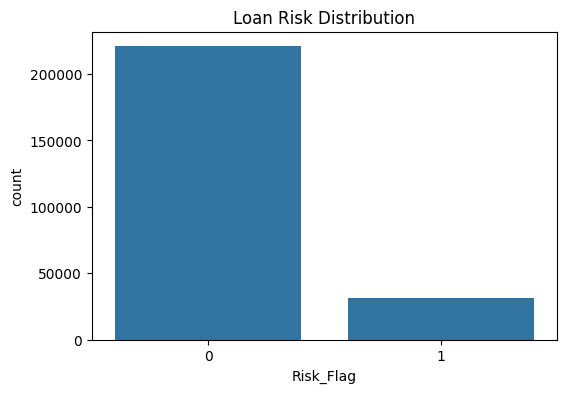

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(
    x="Risk_Flag",
    data=df
)

plt.title("Loan Risk Distribution")
plt.show()

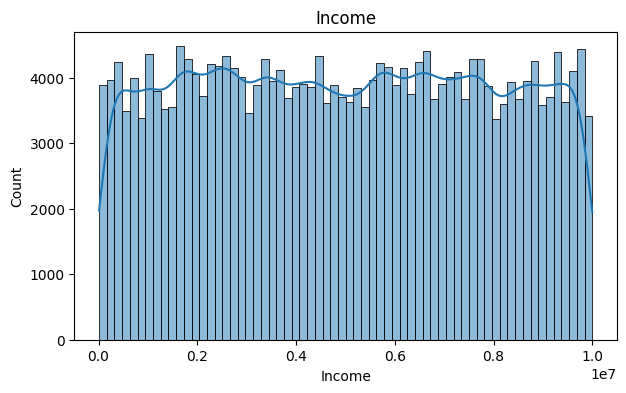

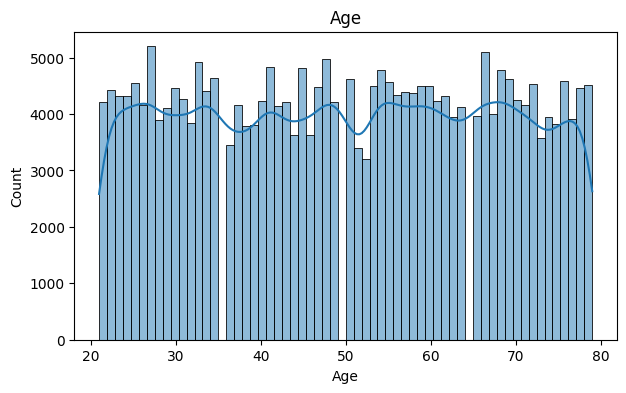

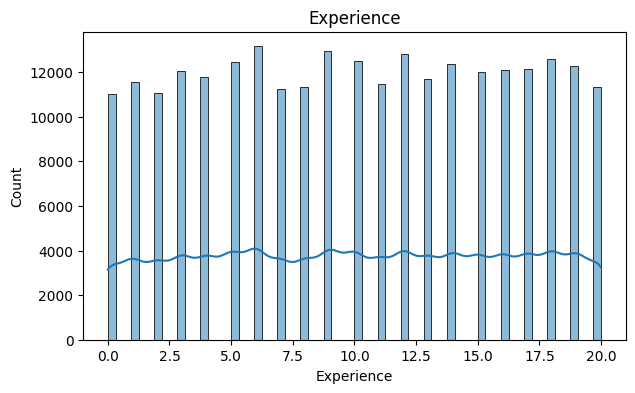

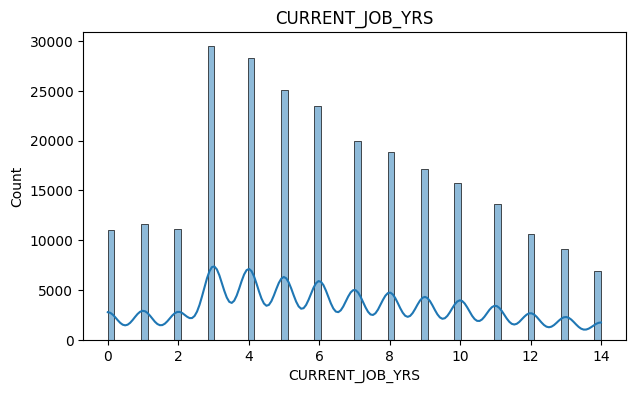

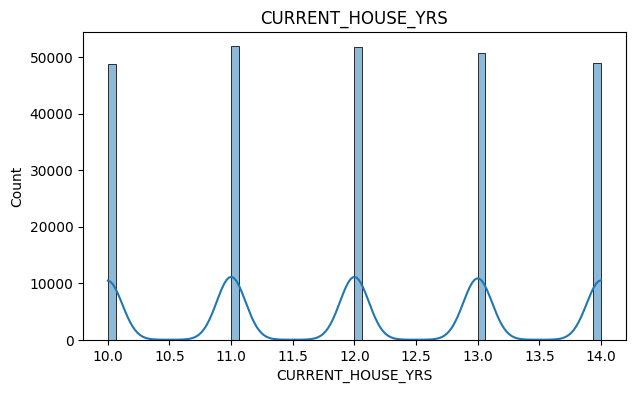

In [37]:
numerical_columns = [
    "Income",
    "Age",
    "Experience",
    "CURRENT_JOB_YRS",
    "CURRENT_HOUSE_YRS"
]

for col in numerical_columns:

    plt.figure(figsize=(7,4))

    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(col)

    plt.show()

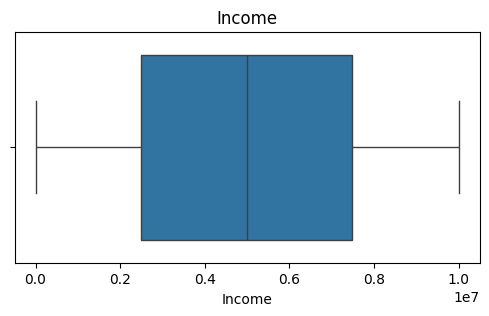

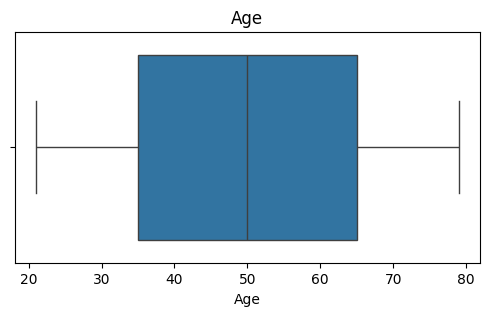

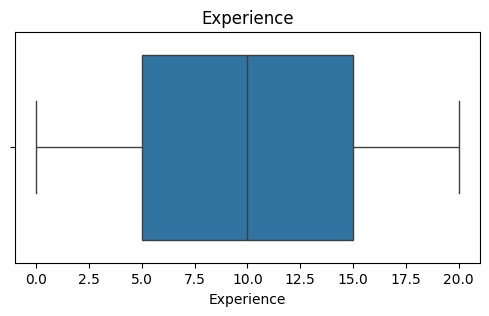

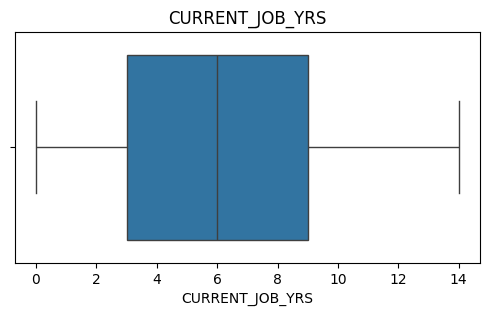

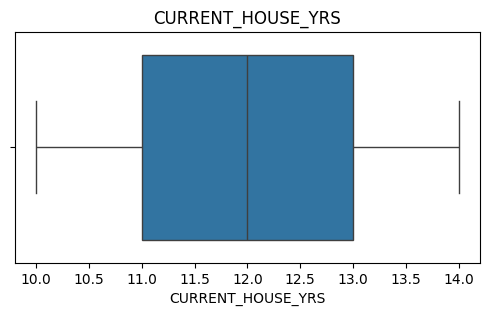

In [38]:
for col in numerical_columns:

    plt.figure(figsize=(6,3))

    sns.boxplot(
        x=df[col]
    )

    plt.title(col)

    plt.show()

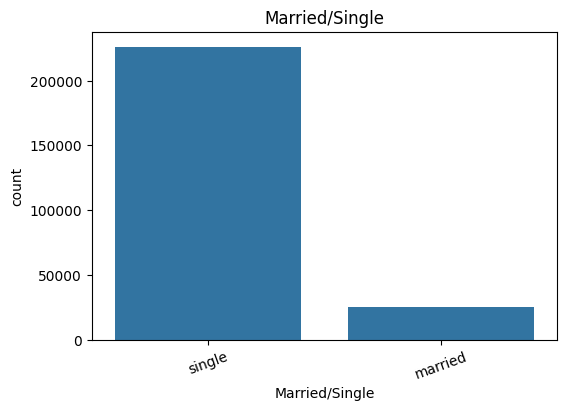

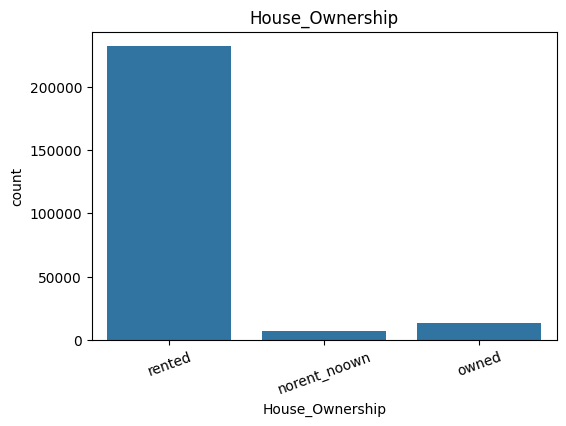

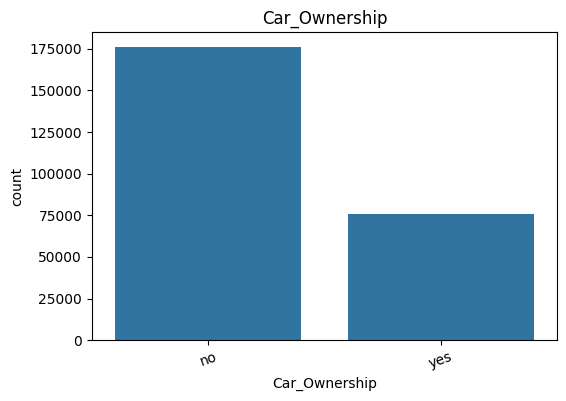

In [39]:
categorical_columns = [

"Married/Single",

"House_Ownership",

"Car_Ownership"

]

for col in categorical_columns:

    plt.figure(figsize=(6,4))

    sns.countplot(
        x=col,
        data=df
    )

    plt.xticks(rotation=20)

    plt.title(col)

    plt.show()

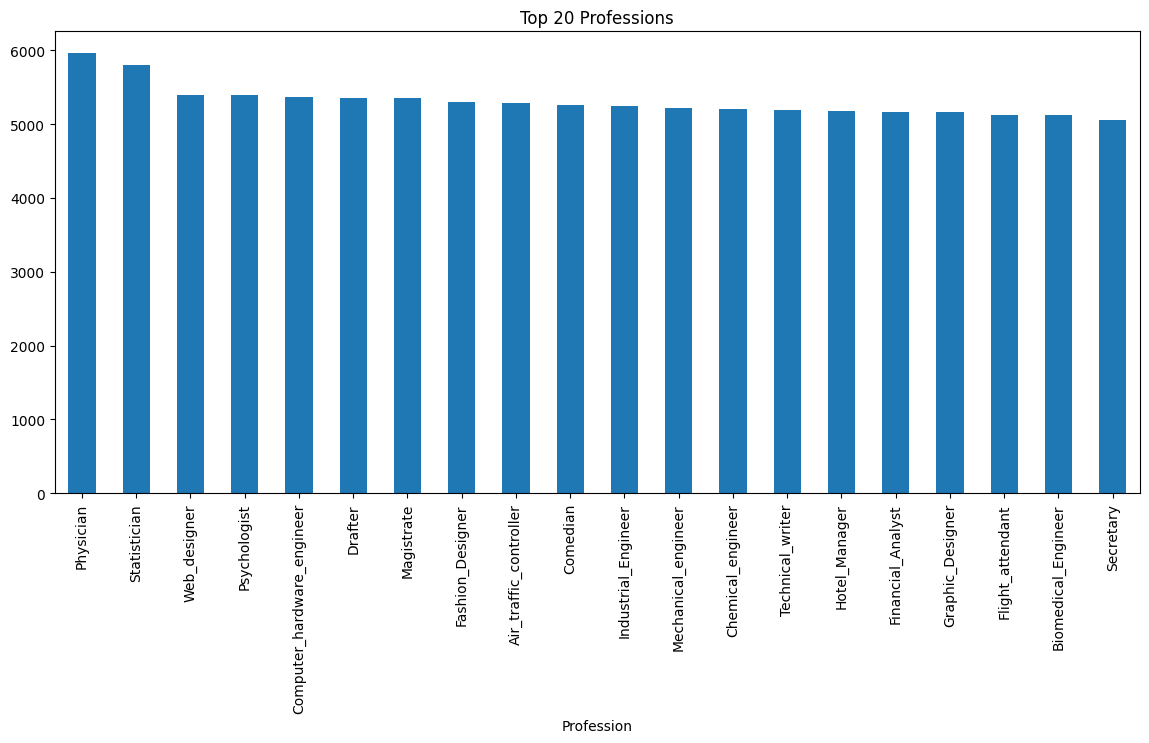

In [40]:
plt.figure(figsize=(14,6))

df["Profession"].value_counts().head(20).plot(kind="bar")

plt.title("Top 20 Professions")

plt.show()

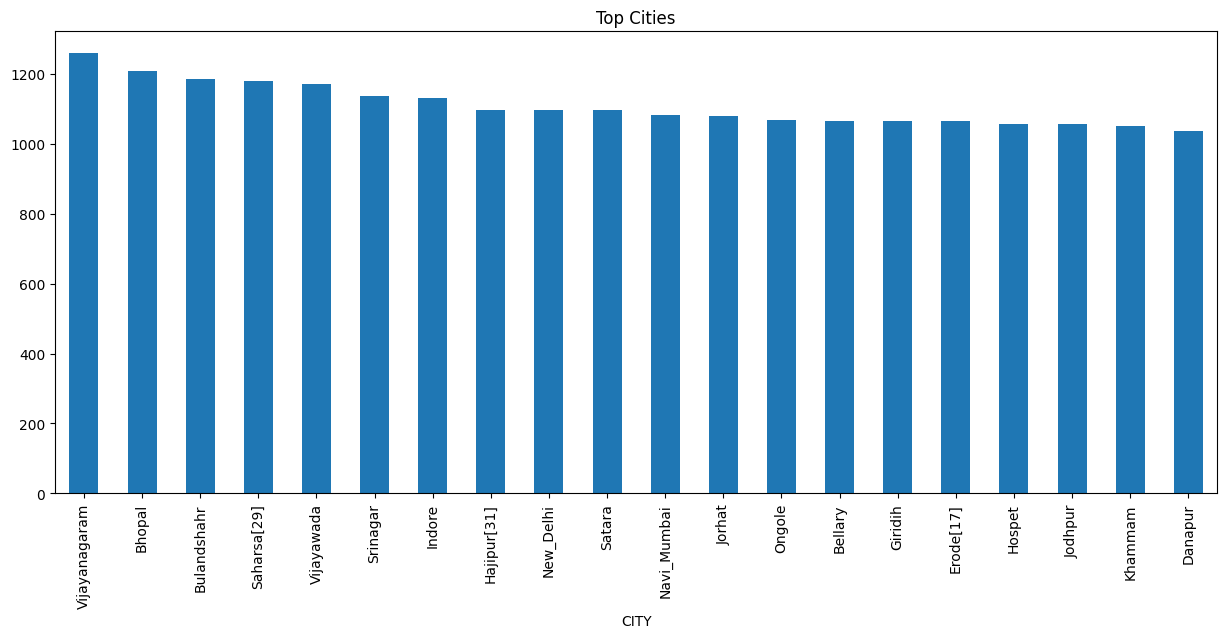

In [41]:
plt.figure(figsize=(15,6))

df["CITY"].value_counts().head(20).plot(kind="bar")

plt.title("Top Cities")

plt.show()

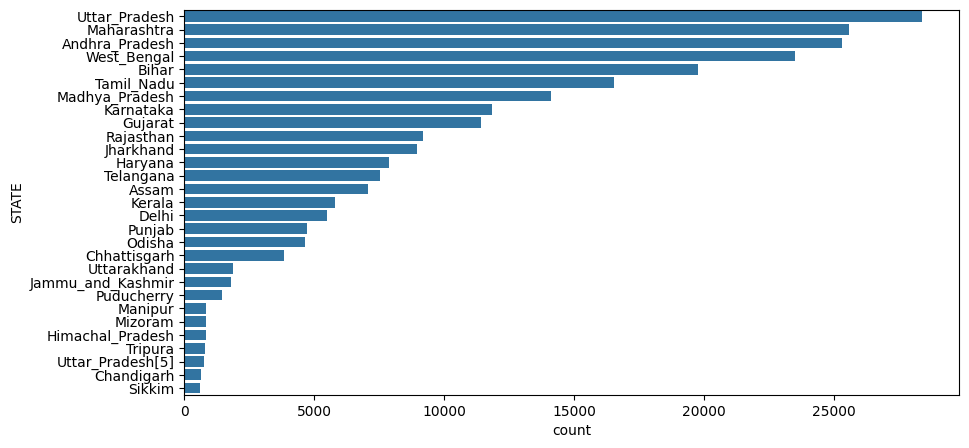

In [42]:
plt.figure(figsize=(10,5))

sns.countplot(
    y="STATE",
    data=df,
    order=df["STATE"].value_counts().index
)

plt.show()

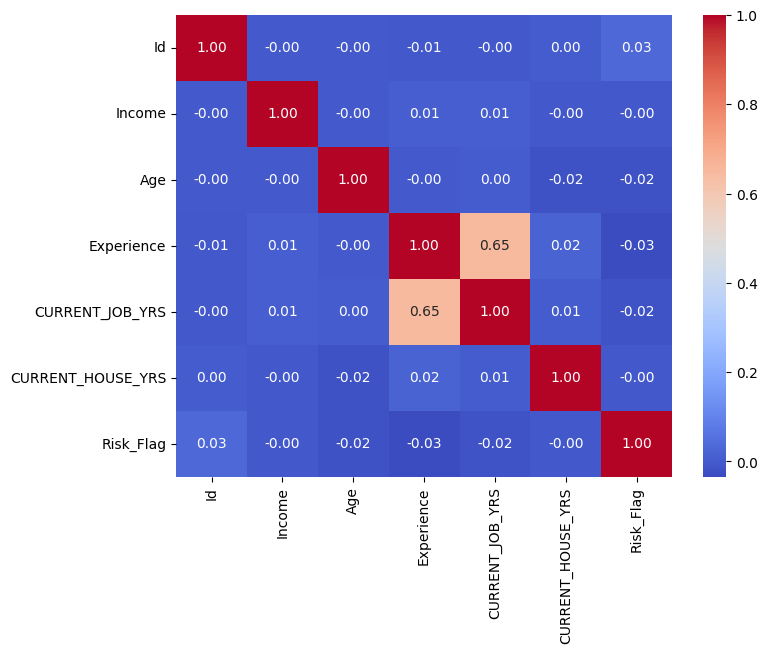

In [43]:
plt.figure(figsize=(8,6))

sns.heatmap(

df.select_dtypes(include="number").corr(),

annot=True,

fmt=".2f",

cmap="coolwarm"

)

plt.show()

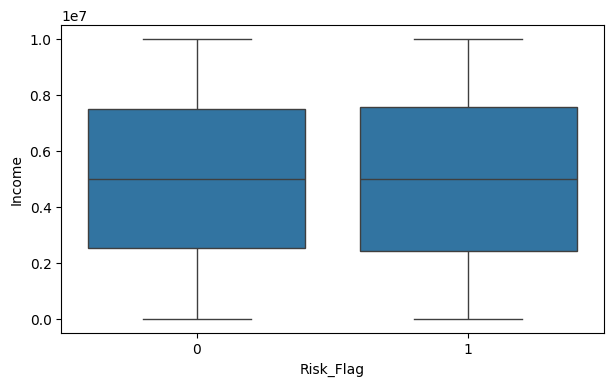

In [44]:
plt.figure(figsize=(7,4))

sns.boxplot(

x="Risk_Flag",

y="Income",

data=df

)

plt.show()

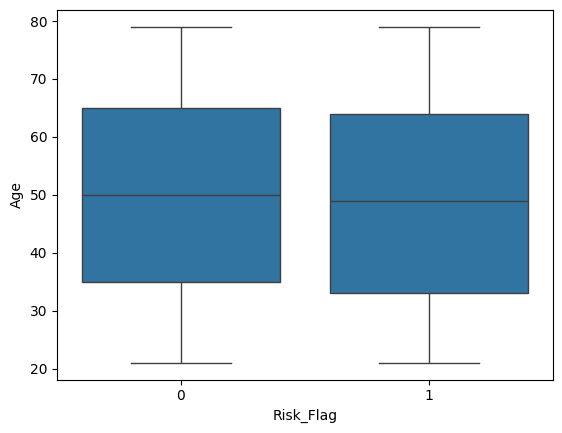

In [45]:
sns.boxplot(

x="Risk_Flag",

y="Age",

data=df

)

plt.show()

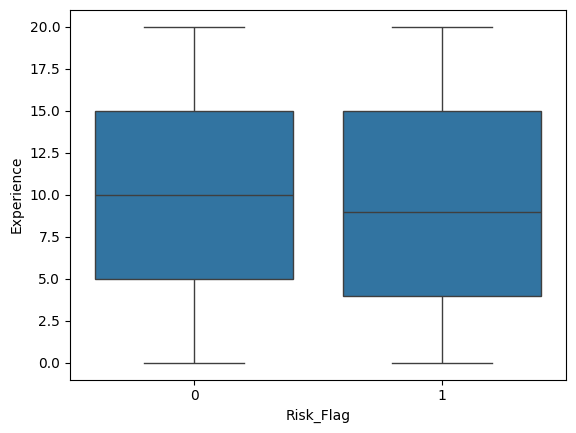

In [46]:
sns.boxplot(

x="Risk_Flag",

y="Experience",

data=df

)

plt.show()

In [47]:
df["Income_per_Experience"] = df["Income"] / (df["Experience"] + 1)

In [48]:
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[18,30,45,60,80],
    labels=["Young","Adult","Middle","Senior"]
)

In [49]:
df["Career_Stability"] = (
    df["CURRENT_JOB_YRS"] +
    df["CURRENT_HOUSE_YRS"]
)

In [50]:
df["Experience_Ratio"] = (
    df["Experience"] /
    df["Age"]
)

In [51]:
df["Risk_Flag"].value_counts()

Risk_Flag
0    221004
1     30996
Name: count, dtype: int64

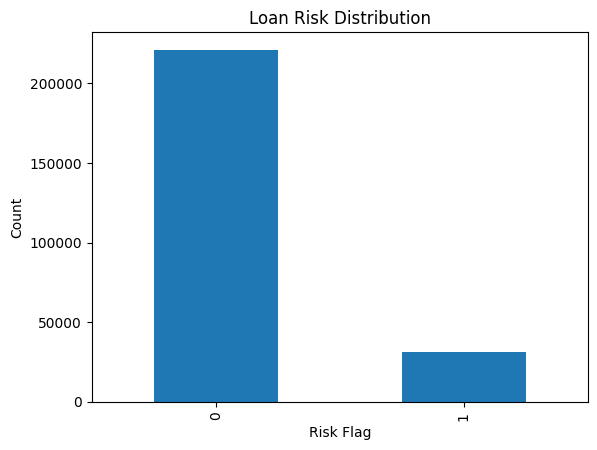

In [52]:
import matplotlib.pyplot as plt

df["Risk_Flag"].value_counts().plot(kind="bar")

plt.title("Loan Risk Distribution")
plt.xlabel("Risk Flag")
plt.ylabel("Count")
plt.show()

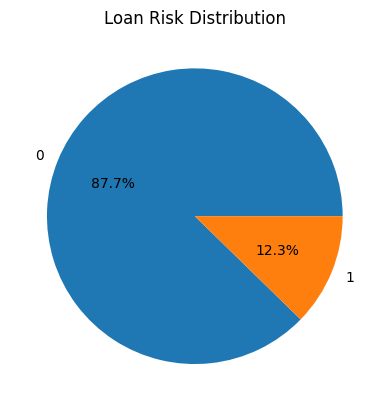

In [53]:
df["Risk_Flag"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Loan Risk Distribution")
plt.show()

In [54]:
numerical = [
    "Income",
    "Age",
    "Experience",
    "CURRENT_JOB_YRS",
    "CURRENT_HOUSE_YRS"
]

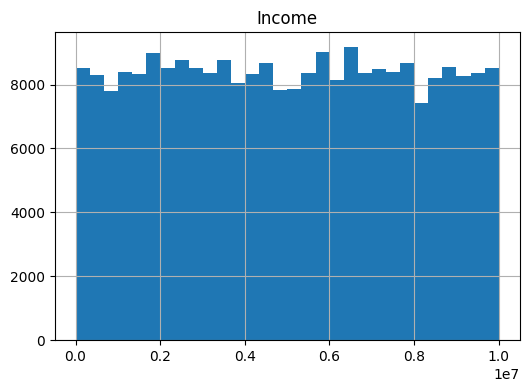

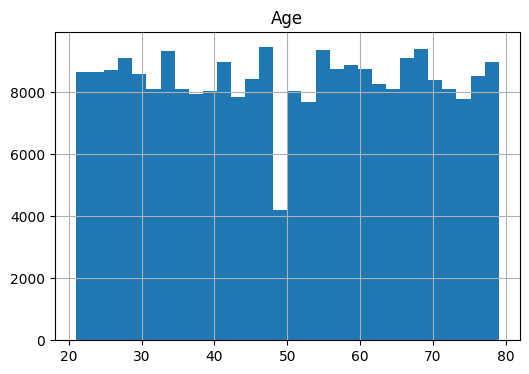

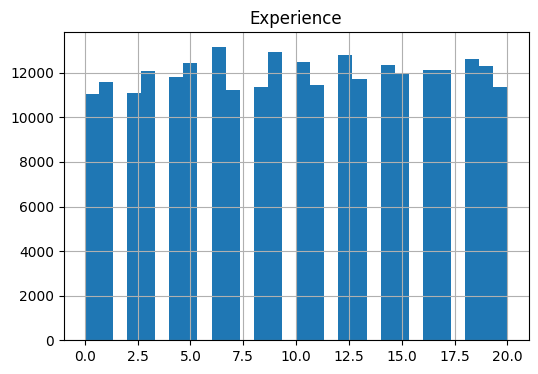

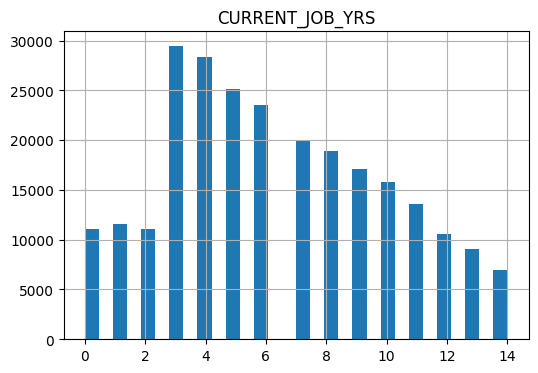

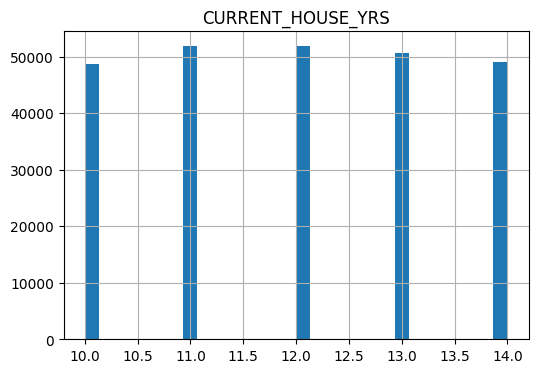

In [55]:
for col in numerical:

    plt.figure(figsize=(6,4))

    df[col].hist(bins=30)

    plt.title(col)

    plt.show()

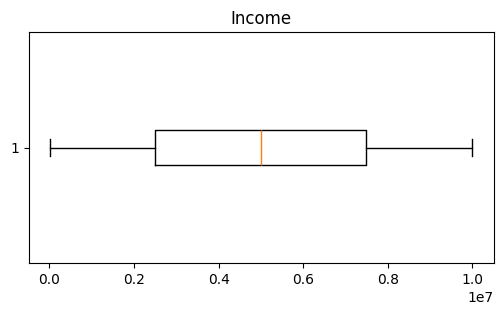

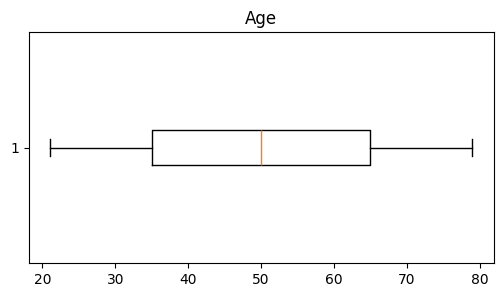

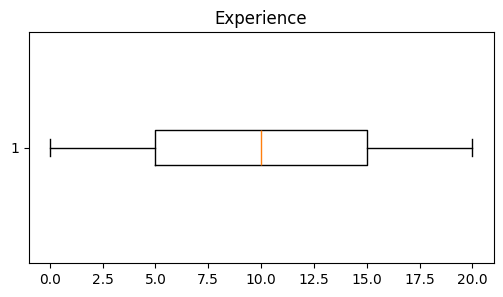

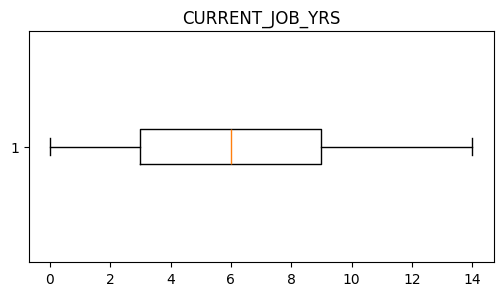

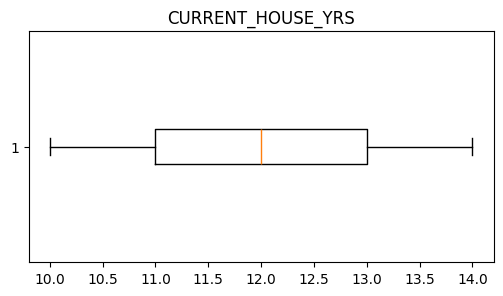

In [56]:
for col in numerical:

    plt.figure(figsize=(6,3))

    plt.boxplot(df[col], vert=False)

    plt.title(col)

    plt.show()

In [57]:
categorical = [

    "Married/Single",

    "House_Ownership",

    "Car_Ownership",

    "Profession",

    "STATE"

]

In [58]:
for col in categorical:

    print("="*50)

    print(col)

    print(df[col].value_counts().head(10))

Married/Single
Married/Single
single     226272
married     25728
Name: count, dtype: int64
House_Ownership
House_Ownership
rented          231898
owned            12918
norent_noown      7184
Name: count, dtype: int64
Car_Ownership
Car_Ownership
no     176000
yes     76000
Name: count, dtype: int64
Profession
Profession
Physician                     5957
Statistician                  5806
Web_designer                  5397
Psychologist                  5390
Computer_hardware_engineer    5372
Drafter                       5359
Magistrate                    5357
Fashion_Designer              5304
Air_traffic_controller        5281
Comedian                      5259
Name: count, dtype: int64
STATE
STATE
Uttar_Pradesh     28400
Maharashtra       25562
Andhra_Pradesh    25297
West_Bengal       23483
Bihar             19780
Tamil_Nadu        16537
Madhya_Pradesh    14122
Karnataka         11855
Gujarat           11408
Rajasthan          9174
Name: count, dtype: int64


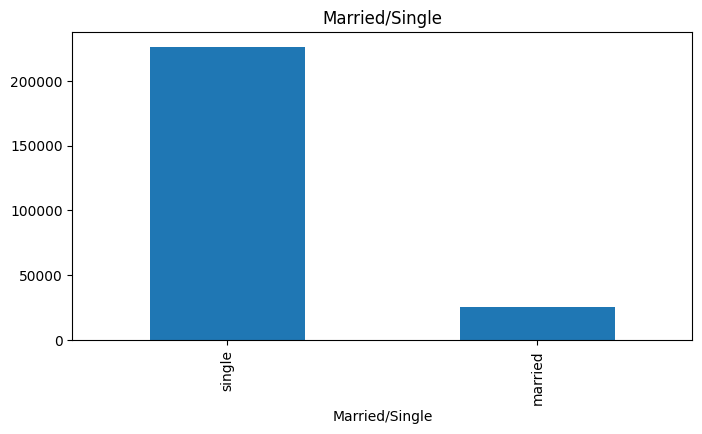

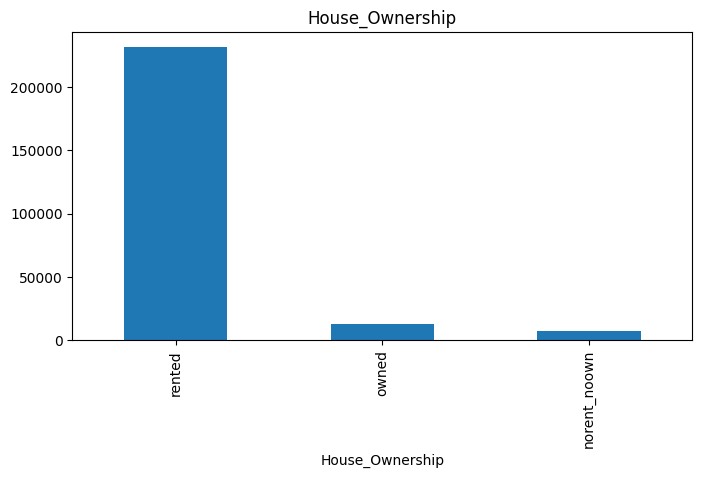

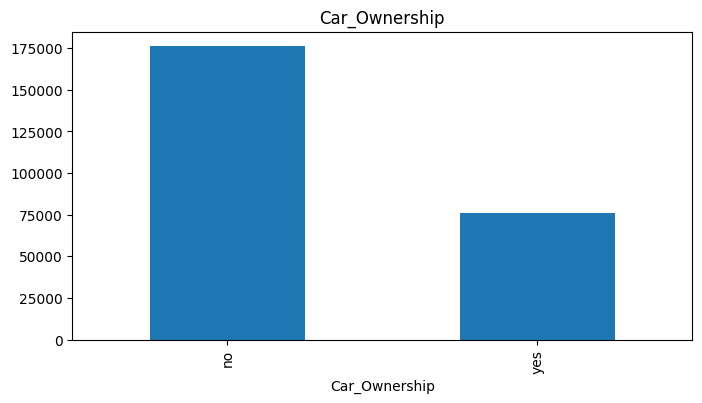

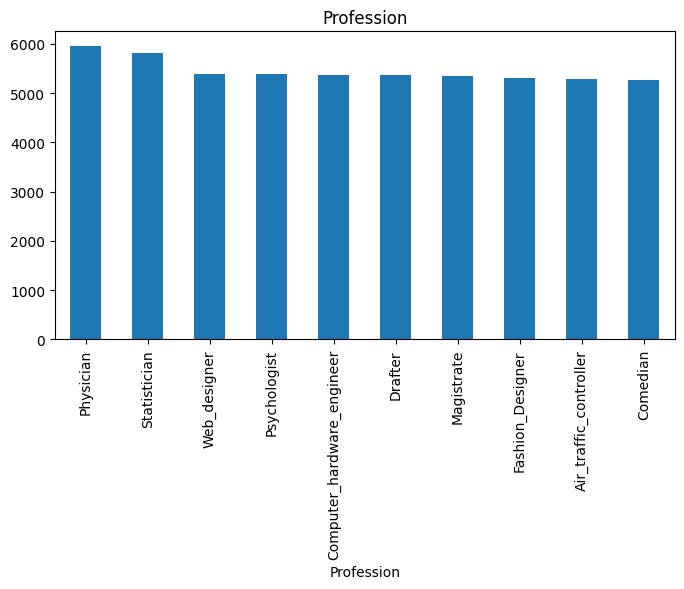

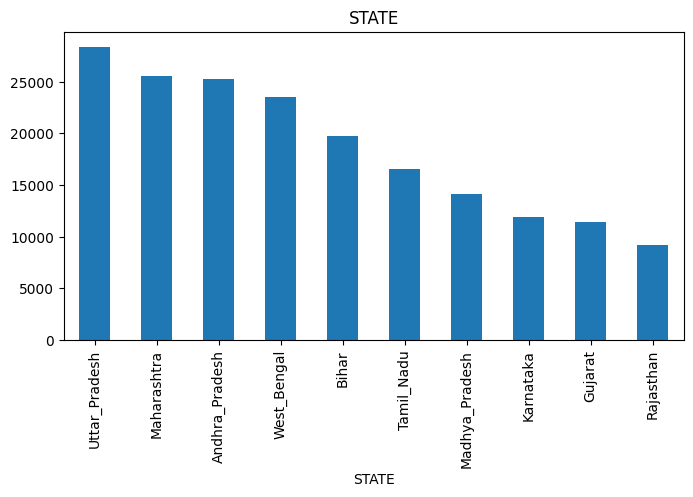

In [59]:
for col in categorical:

    plt.figure(figsize=(8,4))

    df[col].value_counts().head(10).plot(kind="bar")

    plt.title(col)

    plt.show()

In [60]:
import pandas as pd

pd.crosstab(
    df["House_Ownership"],
    df["Risk_Flag"]
)

Risk_Flag,0,1
House_Ownership,,
norent_noown,6469,715
owned,11758,1160
rented,202777,29121


In [61]:
pd.crosstab(df["Married/Single"], df["Risk_Flag"])

pd.crosstab(df["Car_Ownership"], df["Risk_Flag"])

pd.crosstab(df["Profession"], df["Risk_Flag"])

pd.crosstab(df["STATE"], df["Risk_Flag"])

Risk_Flag,0,1
STATE,,
Andhra_Pradesh,22362,2935
Assam,6132,930
Bihar,17197,2583
Chandigarh,595,61
Chhattisgarh,3323,511
Delhi,4916,574
Gujarat,10065,1343
Haryana,6910,980
Himachal_Pradesh,722,111


In [62]:
corr = df.select_dtypes(include="number").corr()

corr

,Id,Income,Age,Experience,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag,Income_per_Experience,Career_Stability,Experience_Ratio
Id,1.000000,-0.001324,-0.001816,-0.005810,-0.003250,0.001972,0.032153,0.004562,-0.002324,-0.002801
Income,-0.001324,1.000000,-0.000652,0.006422,0.007045,-0.002397,-0.003091,0.373925,0.005708,0.003750
Age,-0.001816,-0.000652,1.000000,-0.001118,0.002154,-0.020134,-0.021809,-0.005155,-0.005191,-0.500438
Experience,-0.005810,0.006422,-0.001118,1.000000,0.646098,0.019309,-0.034523,-0.554180,0.609058,0.786875
CURRENT_JOB_YRS,-0.003250,0.007045,0.002154,0.646098,1.000000,0.005372,-0.016942,-0.495124,0.933908,0.508531
CURRENT_HOUSE_YRS,0.001972,-0.002397,-0.020134,0.019309,0.005372,1.000000,-0.004375,-0.010136,0.362524,0.030739
Risk_Flag,0.032153,-0.003091,-0.021809,-0.034523,-0.016942,-0.004375,1.000000,0.025543,-0.017354,-0.012180
Income_per_Experience,0.004562,0.373925,-0.005155,-0.554180,-0.495124,-0.010136,0.025543,1.000000,-0.465073,-0.436003
Career_Stability,-0.002324,0.005708,-0.005191,0.609058,0.933908,0.362524,-0.017354,-0.465073,1.000000,0.484934
Experience_Ratio,-0.002801,0.003750,-0.500438,0.786875,0.508531,0.030739,-0.012180,-0.436003,0.484934,1.000000


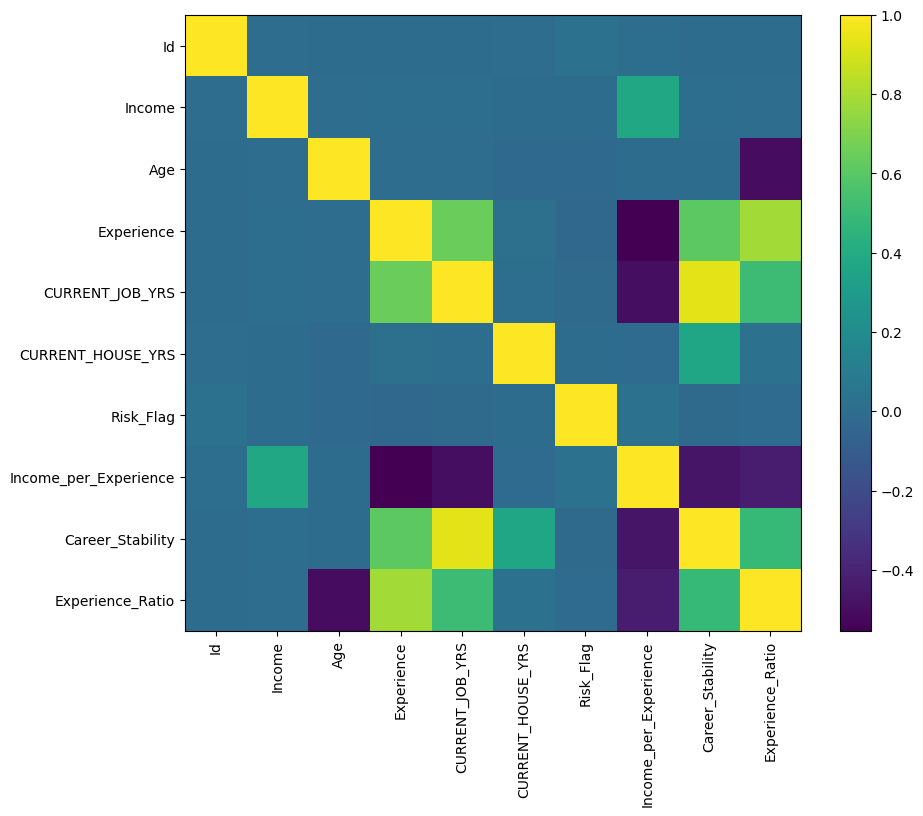

In [63]:
plt.figure(figsize=(10,8))

plt.imshow(corr)

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)

plt.yticks(range(len(corr.columns)), corr.columns)

plt.show()

In [64]:
# ==========================================
# FEATURE ENGINEERING
# ==========================================

# 1. Income Per Experience
df["Income_Per_Experience"] = (
    df["Income"] /
    (df["Experience"] + 1)
)

# 2. Age Group
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[20,30,40,50,60,80],
    labels=["20s","30s","40s","50s","60+"]
)

# 3. Career Stability
df["Career_Stability"] = (
    df["CURRENT_JOB_YRS"] +
    df["CURRENT_HOUSE_YRS"]
)

# 4. Experience Ratio
df["Experience_Ratio"] = (
    df["Experience"] /
    df["Age"]
)

# ==========================================
# ADD THESE NEW FEATURES HERE
# ==========================================

# 5. Financial Maturity
df["Financial_Maturity"] = (
    df["Age"] *
    df["CURRENT_JOB_YRS"]
)

# 6. Long Term Resident
df["Long_Term_Resident"] = (
    df["CURRENT_HOUSE_YRS"] >= 12
).astype(int)

# 7. Career Start Age
df["Career_Start_Age"] = (
    df["Age"] -
    df["Experience"]
)

In [65]:
df.head()

,Id,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag,Income_per_Experience,Age_Group,Career_Stability,Experience_Ratio,Income_Per_Experience,Financial_Maturity,Long_Term_Resident,Career_Start_Age
0,1,1303834,23,3,single,rented,no,Mechanical_engineer,Rewa,Madhya_Pradesh,3,13,0,3.259585e+05,20s,16,0.130435,3.259585e+05,69,1,20
1,2,7574516,40,10,single,rented,no,Software_Developer,Parbhani,Maharashtra,9,13,0,6.885924e+05,30s,22,0.250000,6.885924e+05,360,1,30
2,3,3991815,66,4,married,rented,no,Technical_writer,Alappuzha,Kerala,4,10,0,7.983630e+05,60+,14,0.060606,7.983630e+05,264,0,62
3,4,6256451,41,2,single,rented,yes,Software_Developer,Bhubaneswar,Odisha,2,12,1,2.085484e+06,40s,14,0.048780,2.085484e+06,82,1,39
4,5,5768871,47,11,single,rented,no,Civil_servant,Tiruchirappalli[10],Tamil_Nadu,3,14,1,4.807392e+05,40s,17,0.234043,4.807392e+05,141,1,36


In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252000 entries, 0 to 251999
Data columns (total 21 columns):
 #   Column                 Non-Null Count   Dtype   
---  ------                 --------------   -----   
 0   Id                     252000 non-null  int64   
 1   Income                 252000 non-null  int64   
 2   Age                    252000 non-null  int64   
 3   Experience             252000 non-null  int64   
 4   Married/Single         252000 non-null  object  
 5   House_Ownership        252000 non-null  object  
 6   Car_Ownership          252000 non-null  object  
 7   Profession             252000 non-null  object  
 8   CITY                   252000 non-null  object  
 9   STATE                  252000 non-null  object  
 10  CURRENT_JOB_YRS        252000 non-null  int64   
 11  CURRENT_HOUSE_YRS      252000 non-null  int64   
 12  Risk_Flag              252000 non-null  int64   
 13  Income_per_Experience  252000 non-null  float64 
 14  Age_Group           

In [67]:
df.drop(columns=["Income_Per_Experience"], inplace=True)

In [68]:
print(df.columns.tolist())

['Id', 'Income', 'Age', 'Experience', 'Married/Single', 'House_Ownership', 'Car_Ownership', 'Profession', 'CITY', 'STATE', 'CURRENT_JOB_YRS', 'CURRENT_HOUSE_YRS', 'Risk_Flag', 'Income_per_Experience', 'Age_Group', 'Career_Stability', 'Experience_Ratio', 'Financial_Maturity', 'Long_Term_Resident', 'Career_Start_Age']


In [69]:
engineered_features = [
    "Income_per_Experience",
    "Age_Group",
    "Career_Stability",
    "Experience_Ratio",
    "Stable_Employee",
    "Financial_Maturity",
    "Long_Term_Resident",
    "Career_Start_Age"
]

missing = [col for col in engineered_features if col not in df.columns]

print("Missing columns:", missing)

Missing columns: ['Stable_Employee']


In [70]:
df["Stable_Employee"] = (
    df["CURRENT_JOB_YRS"] >= 5
).astype(int)

In [71]:
df["Stable_Employee"].value_counts()

Stable_Employee
1    160496
0     91504
Name: count, dtype: int64

In [72]:
missing = [c for c in engineered_features if c not in df.columns]
print(missing)

[]


In [73]:
df[engineered_features].head()

,Income_per_Experience,Age_Group,Career_Stability,Experience_Ratio,Stable_Employee,Financial_Maturity,Long_Term_Resident,Career_Start_Age
0,3.259585e+05,20s,16,0.130435,0,69,1,20
1,6.885924e+05,30s,22,0.250000,1,360,1,30
2,7.983630e+05,60+,14,0.060606,0,264,0,62
3,2.085484e+06,40s,14,0.048780,0,82,1,39
4,4.807392e+05,40s,17,0.234043,0,141,1,36


In [74]:
print(df2.columns.tolist())

['loan_id', 'no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_status']


In [75]:
df2.columns = df2.columns.str.strip()

In [76]:
print(df2.columns.tolist())

['loan_id', 'no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_status']


In [77]:
df2["loan_status"]

0        Approved
1        Rejected
2        Rejected
3        Rejected
4        Rejected
          ...    
4264     Rejected
4265     Approved
4266     Rejected
4267     Approved
4268     Approved
Name: loan_status, Length: 4269, dtype: object

In [78]:
df2["education"]

0            Graduate
1        Not Graduate
2            Graduate
3            Graduate
4        Not Graduate
            ...      
4264         Graduate
4265     Not Graduate
4266     Not Graduate
4267     Not Graduate
4268         Graduate
Name: education, Length: 4269, dtype: object

In [79]:
df2["income_annum"]

0       9600000
1       4100000
2       9100000
3       8200000
4       9800000
         ...   
4264    1000000
4265    3300000
4266    6500000
4267    4100000
4268    9200000
Name: income_annum, Length: 4269, dtype: int64

In [80]:
df.columns = df.columns.str.strip()
df2.columns = df2.columns.str.strip()
df3.columns = df3.columns.str.strip()

In [81]:
df2.columns = df2.columns.str.strip()
print(df2.columns.tolist())

['loan_id', 'no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_status']


In [82]:
print(df2["loan_status"].value_counts())

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64


In [83]:
print(df2["loan_status"].value_counts(normalize=True) * 100)

loan_status
Approved    62.215976
Rejected    37.784024
Name: proportion, dtype: float64


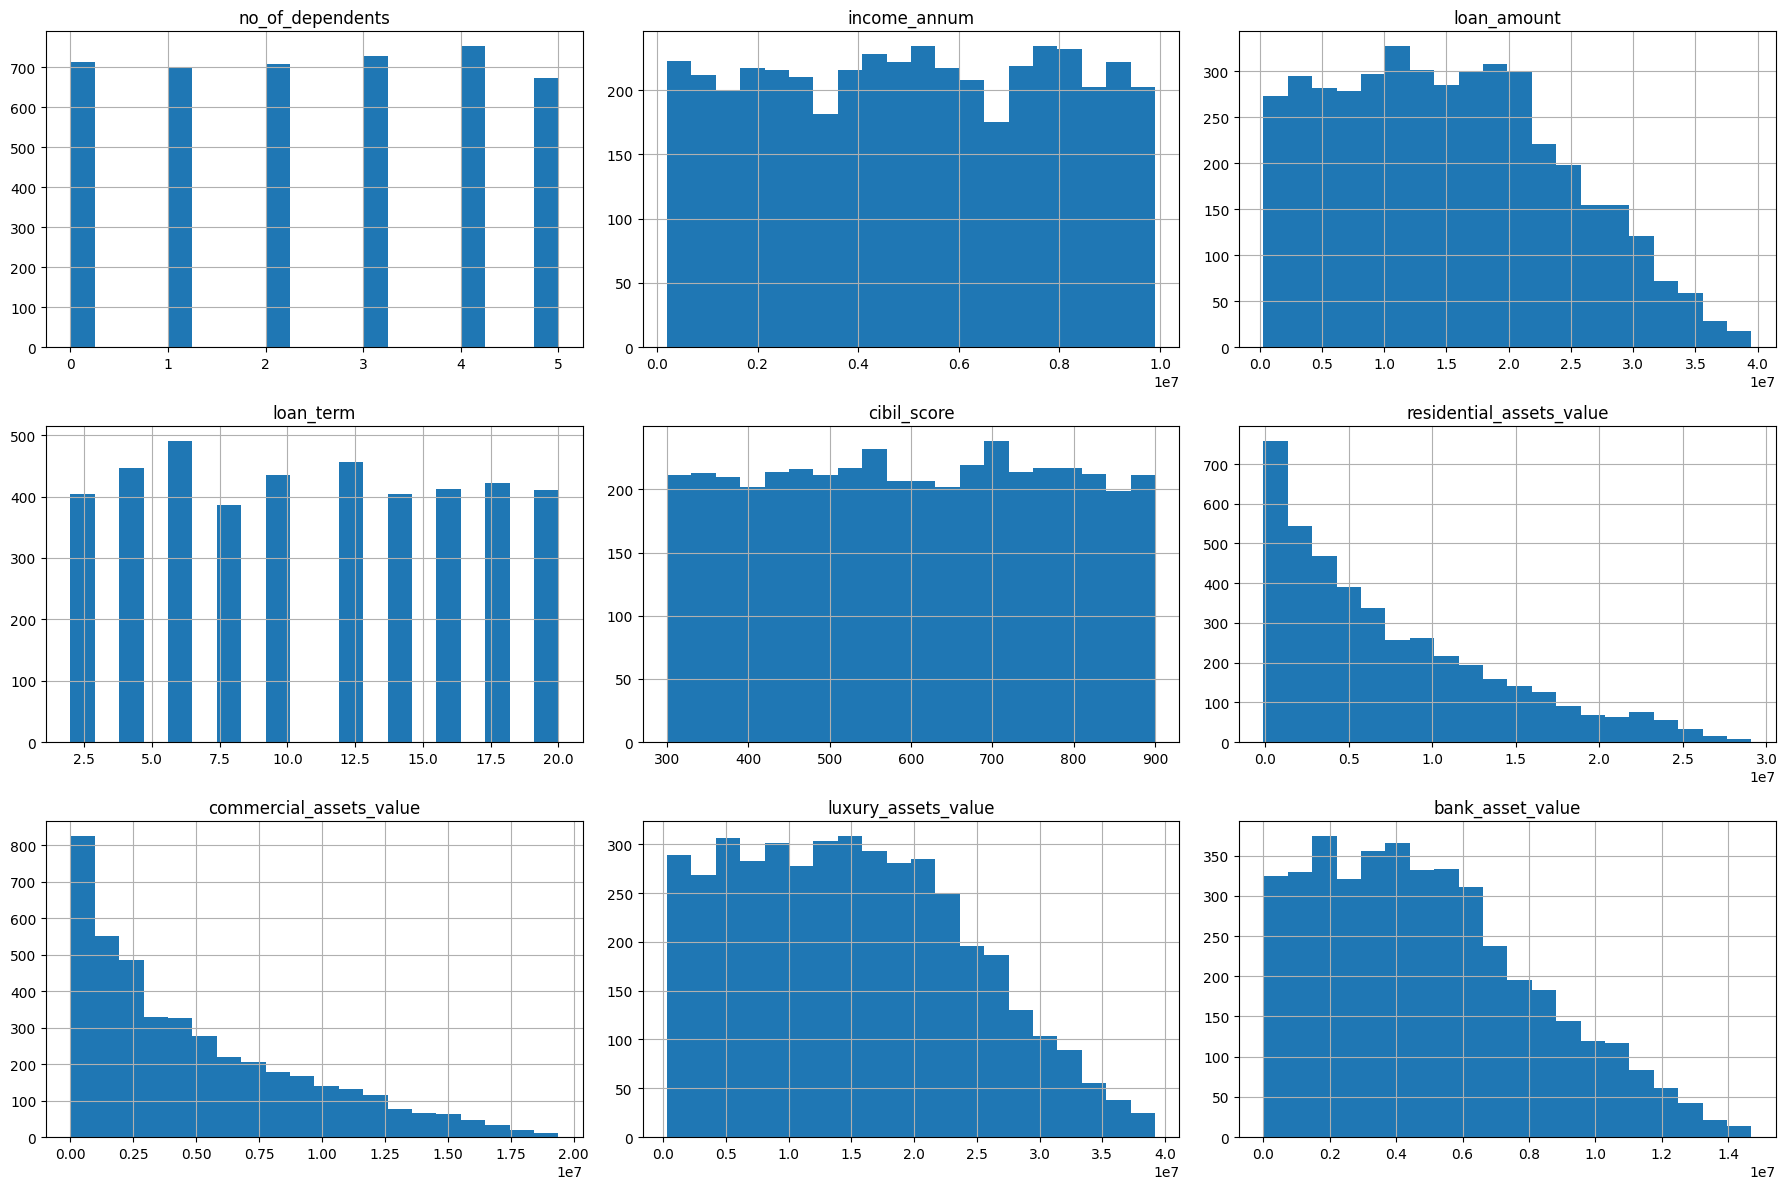

In [84]:
num_cols = [
    "no_of_dependents",
    "income_annum",
    "loan_amount",
    "loan_term",
    "cibil_score",
    "residential_assets_value",
    "commercial_assets_value",
    "luxury_assets_value",
    "bank_asset_value"
]

df2[num_cols].hist(figsize=(18,12), bins=20)

plt.tight_layout()
plt.show()

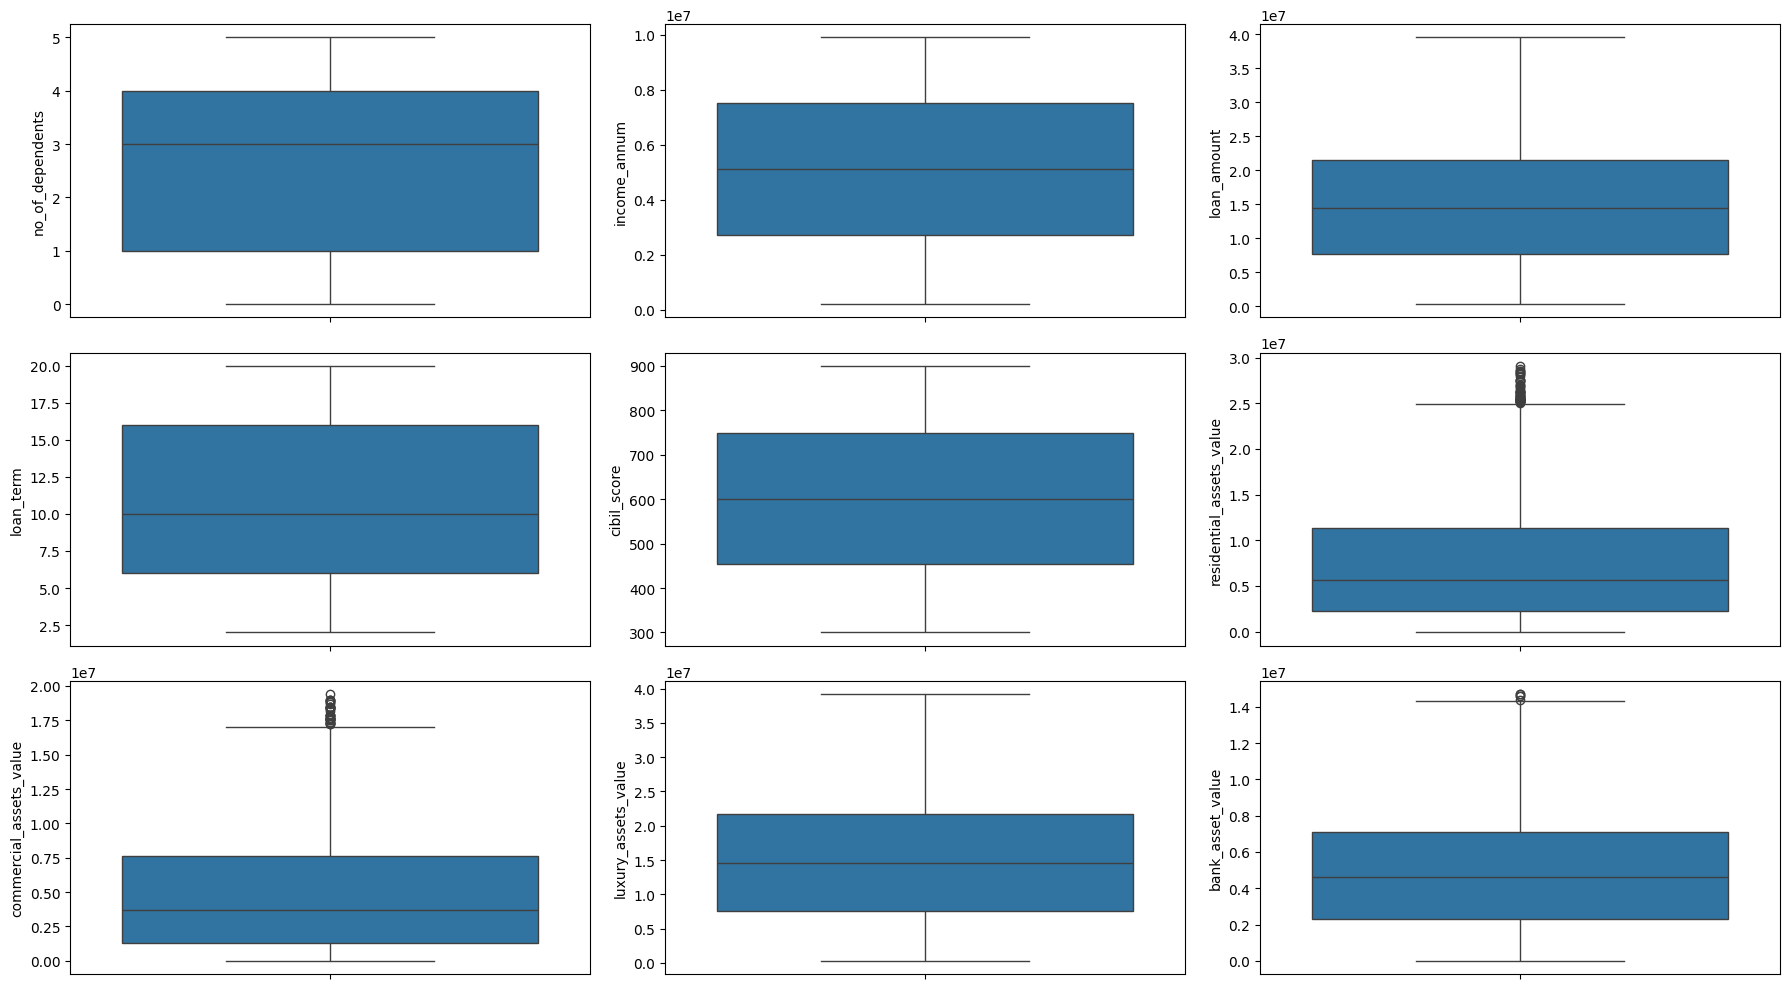

In [85]:
plt.figure(figsize=(18,10))

for i, col in enumerate(num_cols):
    plt.subplot(3,3,i+1)
    sns.boxplot(y=df2[col])

plt.tight_layout()
plt.show()

In [86]:
cat_cols = [
    "education",
    "self_employed"
]

for col in cat_cols:
    print("="*50)
    print(col)
    print(df2[col].value_counts())

education
education
Graduate        2144
Not Graduate    2125
Name: count, dtype: int64
self_employed
self_employed
Yes    2150
No     2119
Name: count, dtype: int64


In [87]:
pd.crosstab(df2["education"], df2["loan_status"])

loan_status,Approved,Rejected
education,,
Graduate,1339,805
Not Graduate,1317,808


In [88]:
pd.crosstab(df2["self_employed"], df2["loan_status"])

loan_status,Approved,Rejected
self_employed,,
No,1318,801
Yes,1338,812


In [89]:
# ===========================
# FEATURE ENGINEERING
# ===========================

# Loan to Income Ratio
df2["Loan_Income_Ratio"] = (
    df2["loan_amount"] /
    df2["income_annum"]
)

# Total Assets
df2["Total_Assets"] = (
    df2["residential_assets_value"] +
    df2["commercial_assets_value"] +
    df2["luxury_assets_value"] +
    df2["bank_asset_value"]
)

# Asset Coverage
df2["Asset_Coverage"] = (
    df2["Total_Assets"] /
    df2["loan_amount"]
)

# Income per Dependent
df2["Income_Per_Dependent"] = (
    df2["income_annum"] /
    (df2["no_of_dependents"] + 1)
)

# High CIBIL
df2["High_CIBIL"] = (
    df2["cibil_score"] >= 700
).astype(int)

# Asset Rich
df2["Asset_Rich"] = (
    df2["Total_Assets"] >
    df2["Total_Assets"].median()
).astype(int)

# Asset Income Ratio
df2["Asset_Income_Ratio"] = (
    df2["Total_Assets"] /
    df2["income_annum"]
)

# Loan per Year
df2["Loan_Per_Year"] = (
    df2["loan_amount"] /
    df2["loan_term"]
)

# Loan per CIBIL
df2["Loan_Per_CIBIL"] = (
    df2["loan_amount"] /
    df2["cibil_score"]
)

In [90]:
df2.info()
df2.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   loan_id                   4269 non-null   int64  
 1   no_of_dependents          4269 non-null   int64  
 2   education                 4269 non-null   object 
 3   self_employed             4269 non-null   object 
 4   income_annum              4269 non-null   int64  
 5   loan_amount               4269 non-null   int64  
 6   loan_term                 4269 non-null   int64  
 7   cibil_score               4269 non-null   int64  
 8   residential_assets_value  4269 non-null   int64  
 9   commercial_assets_value   4269 non-null   int64  
 10  luxury_assets_value       4269 non-null   int64  
 11  bank_asset_value          4269 non-null   int64  
 12  loan_status               4269 non-null   object 
 13  Loan_Income_Ratio         4269 non-null   float64
 14  Total_As

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,Loan_Income_Ratio,Total_Assets,Asset_Coverage,Income_Per_Dependent,High_CIBIL,Asset_Rich,Asset_Income_Ratio,Loan_Per_Year,Loan_Per_CIBIL
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved,3.114583,50700000,1.695652,3.200000e+06,1,1,5.281250,2.491667e+06,38431.876607
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected,2.975610,17000000,1.393443,4.100000e+06,0,0,4.146341,1.525000e+06,29256.594724
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected,3.263736,57700000,1.942761,2.275000e+06,0,1,6.340659,1.485000e+06,58695.652174
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected,3.743902,52700000,1.716612,2.050000e+06,0,1,6.426829,3.837500e+06,65738.758030
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected,2.469388,55000000,2.272727,1.633333e+06,0,1,5.612245,1.210000e+06,63350.785340


In [91]:
df2["Credit_Category"] = pd.cut(
    df2["cibil_score"],
    bins=[300, 550, 650, 750, 900],
    labels=["Poor", "Fair", "Good", "Excellent"],
    include_lowest=True
)

In [92]:
df2["Credit_Category"].isnull().sum()

np.int64(0)

In [93]:
df2["Credit_Category"].value_counts()

Credit_Category
Poor         1789
Excellent    1053
Good          739
Fair          688
Name: count, dtype: int64

In [94]:
df2.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,Loan_Income_Ratio,Total_Assets,Asset_Coverage,Income_Per_Dependent,High_CIBIL,Asset_Rich,Asset_Income_Ratio,Loan_Per_Year,Loan_Per_CIBIL,Credit_Category
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved,3.114583,50700000,1.695652,3.200000e+06,1,1,5.281250,2.491667e+06,38431.876607,Excellent
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected,2.975610,17000000,1.393443,4.100000e+06,0,0,4.146341,1.525000e+06,29256.594724,Poor
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected,3.263736,57700000,1.942761,2.275000e+06,0,1,6.340659,1.485000e+06,58695.652174,Poor
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected,3.743902,52700000,1.716612,2.050000e+06,0,1,6.426829,3.837500e+06,65738.758030,Poor
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected,2.469388,55000000,2.272727,1.633333e+06,0,1,5.612245,1.210000e+06,63350.785340,Poor


In [95]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   loan_id                   4269 non-null   int64   
 1   no_of_dependents          4269 non-null   int64   
 2   education                 4269 non-null   object  
 3   self_employed             4269 non-null   object  
 4   income_annum              4269 non-null   int64   
 5   loan_amount               4269 non-null   int64   
 6   loan_term                 4269 non-null   int64   
 7   cibil_score               4269 non-null   int64   
 8   residential_assets_value  4269 non-null   int64   
 9   commercial_assets_value   4269 non-null   int64   
 10  luxury_assets_value       4269 non-null   int64   
 11  bank_asset_value          4269 non-null   int64   
 12  loan_status               4269 non-null   object  
 13  Loan_Income_Ratio         4269 non-null   float6

In [96]:
pd.crosstab(
    df2["self_employed"],
    df2["loan_status"],
    margins=True
)

loan_status,Approved,Rejected,All
self_employed,,,
No,1318,801,2119
Yes,1338,812,2150
All,2656,1613,4269


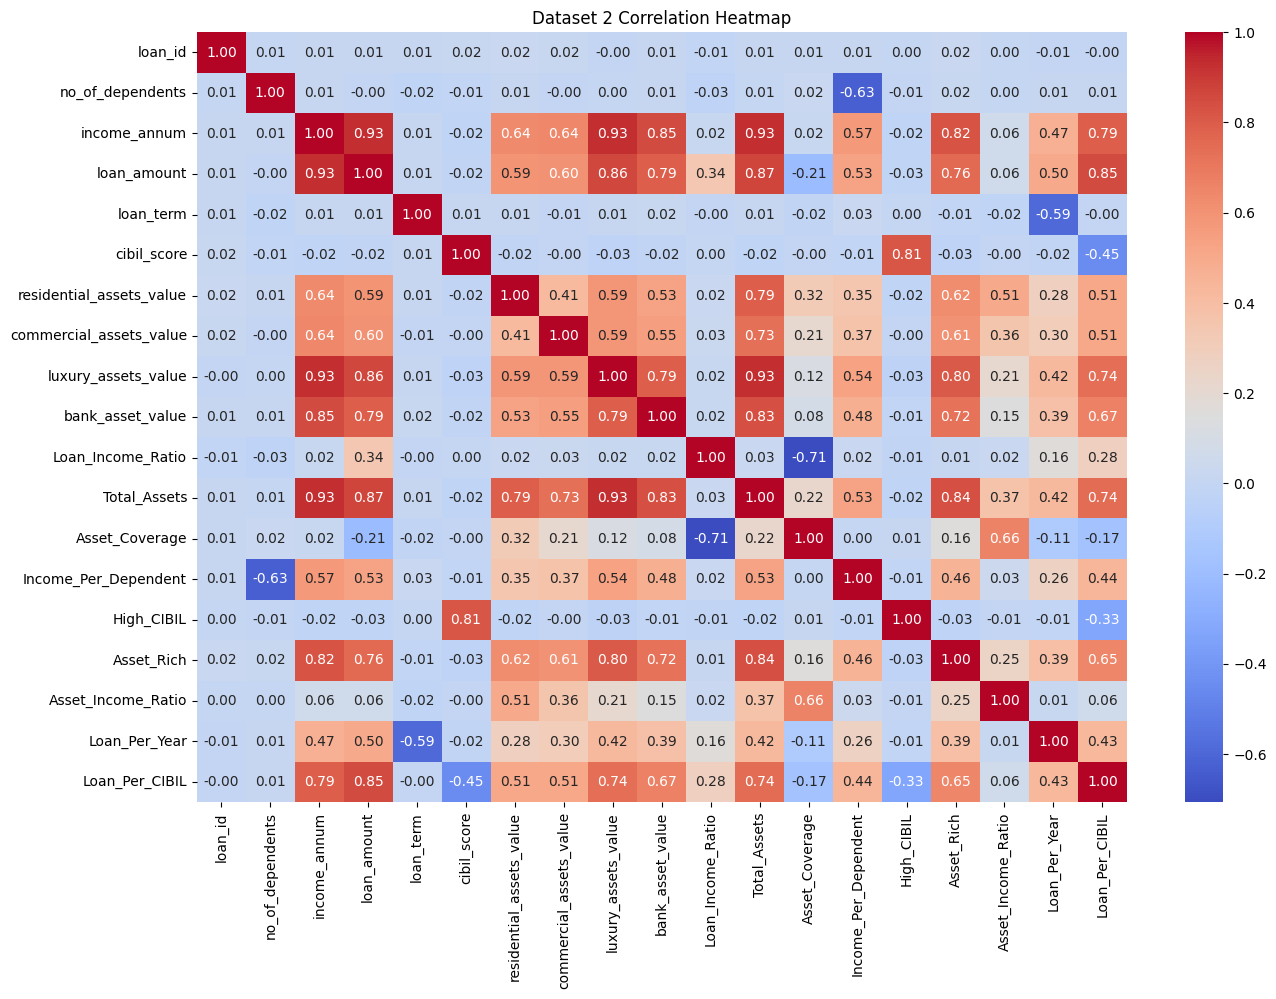

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,10))

numeric_df2 = df2.select_dtypes(include=["int64", "float64"])

sns.heatmap(
    numeric_df2.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Dataset 2 Correlation Heatmap")
plt.show()

In [98]:
print(df3["Default"].value_counts())

print()

print(df3["Default"].value_counts(normalize=True) * 100)

Default
0    225694
1     29653
Name: count, dtype: int64

Default
0    88.387175
1    11.612825
Name: proportion, dtype: float64


In [99]:
categorical_cols = [
    "Education",
    "EmploymentType",
    "MaritalStatus",
    "HasMortgage",
    "HasDependents",
    "LoanPurpose",
    "HasCoSigner"
]

for col in categorical_cols:
    print("=" * 50)
    print(col)
    print(df3[col].value_counts())

Education
Education
Bachelor's     64366
High School    63903
Master's       63541
PhD            63537
Name: count, dtype: int64
EmploymentType
EmploymentType
Part-time        64161
Unemployed       63824
Self-employed    63706
Full-time        63656
Name: count, dtype: int64
MaritalStatus
MaritalStatus
Married     85302
Divorced    85033
Single      85012
Name: count, dtype: int64
HasMortgage
HasMortgage
Yes    127677
No     127670
Name: count, dtype: int64
HasDependents
HasDependents
Yes    127742
No     127605
Name: count, dtype: int64
LoanPurpose
LoanPurpose
Business     51298
Home         51286
Education    51005
Other        50914
Auto         50844
Name: count, dtype: int64
HasCoSigner
HasCoSigner
Yes    127701
No     127646
Name: count, dtype: int64


In [100]:
for col in categorical_cols:
    print("=" * 70)
    print(col)

    display(pd.crosstab(df3[col], df3["Default"]))

Education


Default,0,1
Education,,
Bachelor's,56577,7789
High School,55673,8230
Master's,56633,6908
PhD,56811,6726


EmploymentType


Default,0,1
EmploymentType,,
Full-time,57632,6024
Part-time,56484,7677
Self-employed,56404,7302
Unemployed,55174,8650


MaritalStatus


...

Default,0,1
HasDependents,,
No,111368,16237
Yes,114326,13416


LoanPurpose


Default,0,1
LoanPurpose,,
Auto,44803,6041
Business,44975,6323
Education,44967,6038
Home,46037,5249
Other,44912,6002


HasCoSigner


Default,0,1
HasCoSigner,,
No,111223,16423
Yes,114471,13230


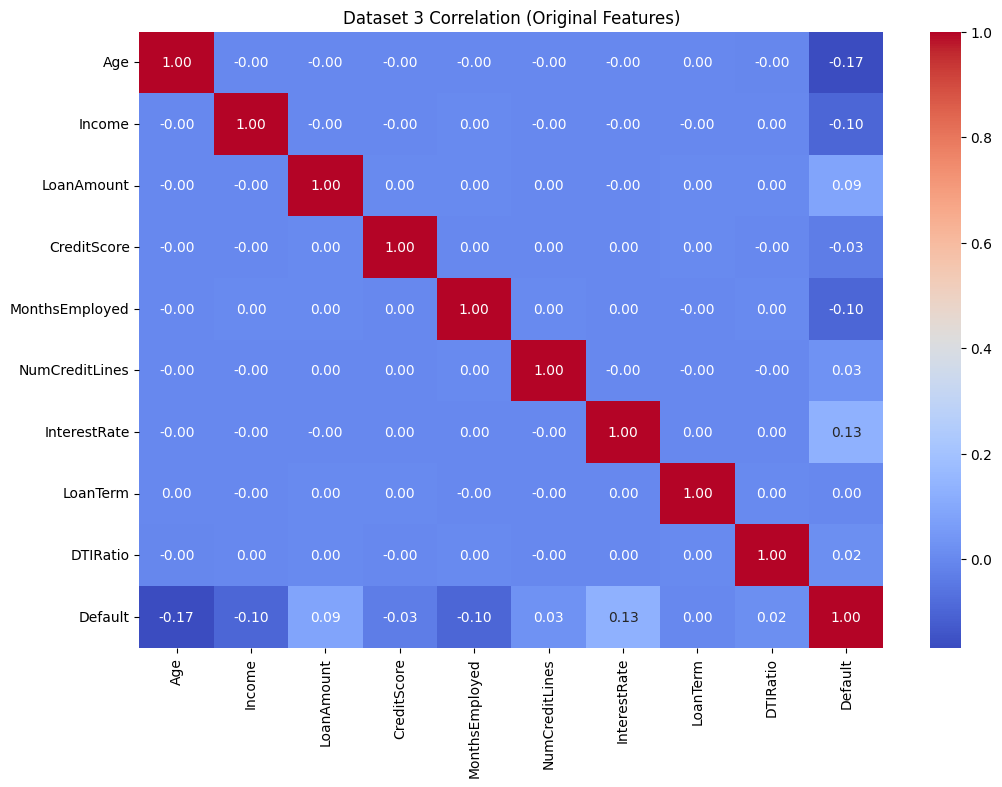

In [101]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df3.select_dtypes(include=["int64", "float64"]).corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Dataset 3 Correlation (Original Features)")
plt.show()

In [102]:
# Income to Loan Ratio
df3["Income_Loan_Ratio"] = df3["Income"] / df3["LoanAmount"]

# Employment Stability
df3["Employment_Stability"] = (
    df3["MonthsEmployed"] / (df3["Age"] * 12)
)

# Credit Utilization Proxy
df3["Credit_per_Line"] = (
    df3["CreditScore"] /
    df3["NumCreditLines"]
)

# Loan Burden
df3["Loan_Burden"] = (
    df3["LoanAmount"] /
    df3["Income"]
)

# Age Category
df3["Age_Group"] = pd.cut(
    df3["Age"],
    bins=[18,30,45,60,70],
    labels=["Young","Adult","Middle","Senior"],
    include_lowest=True
)

# High Credit Score
df3["High_Credit"] = (
    df3["CreditScore"] >= 700
).astype(int)

# Long Employment
df3["Long_Employment"] = (
    df3["MonthsEmployed"] >= 60
).astype(int)

# Monthly Income
df3["Monthly_Income"] = (
    df3["Income"]/12
)

# Estimated EMI
df3["Estimated_EMI"] = (
    df3["LoanAmount"] /
    df3["LoanTerm"]
)

# EMI Burden
df3["EMI_Burden"] = (
    df3["Estimated_EMI"] /
    df3["Monthly_Income"]
)

In [103]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 28 columns):
 #   Column                Non-Null Count   Dtype   
---  ------                --------------   -----   
 0   LoanID                255347 non-null  object  
 1   Age                   255347 non-null  int64   
 2   Income                255347 non-null  int64   
 3   LoanAmount            255347 non-null  int64   
 4   CreditScore           255347 non-null  int64   
 5   MonthsEmployed        255347 non-null  int64   
 6   NumCreditLines        255347 non-null  int64   
 7   InterestRate          255347 non-null  float64 
 8   LoanTerm              255347 non-null  int64   
 9   DTIRatio              255347 non-null  float64 
 10  Education             255347 non-null  object  
 11  EmploymentType        255347 non-null  object  
 12  MaritalStatus         255347 non-null  object  
 13  HasMortgage           255347 non-null  object  
 14  HasDependents         255347 non-nul

In [104]:
df3.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default,Income_Loan_Ratio,Employment_Stability,Credit_per_Line,Loan_Burden,Age_Group,High_Credit,Long_Employment,Monthly_Income,Estimated_EMI,EMI_Burden
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0,1.699923,0.119048,130.000000,0.588262,Middle,0,1,7166.166667,1405.194444,0.196087
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0,0.405272,0.018116,458.000000,2.467481,Senior,0,0,4202.666667,2074.000000,0.493496
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1,0.651825,0.047101,150.333333,1.534154,Middle,0,0,7017.333333,5382.833333,0.767077
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0,0.707895,0.000000,247.666667,1.412638,Adult,1,0,2642.750000,1866.625000,0.706319
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0,2.236240,0.011111,158.250000,0.447179,Middle,0,0,1703.083333,190.395833,0.111795


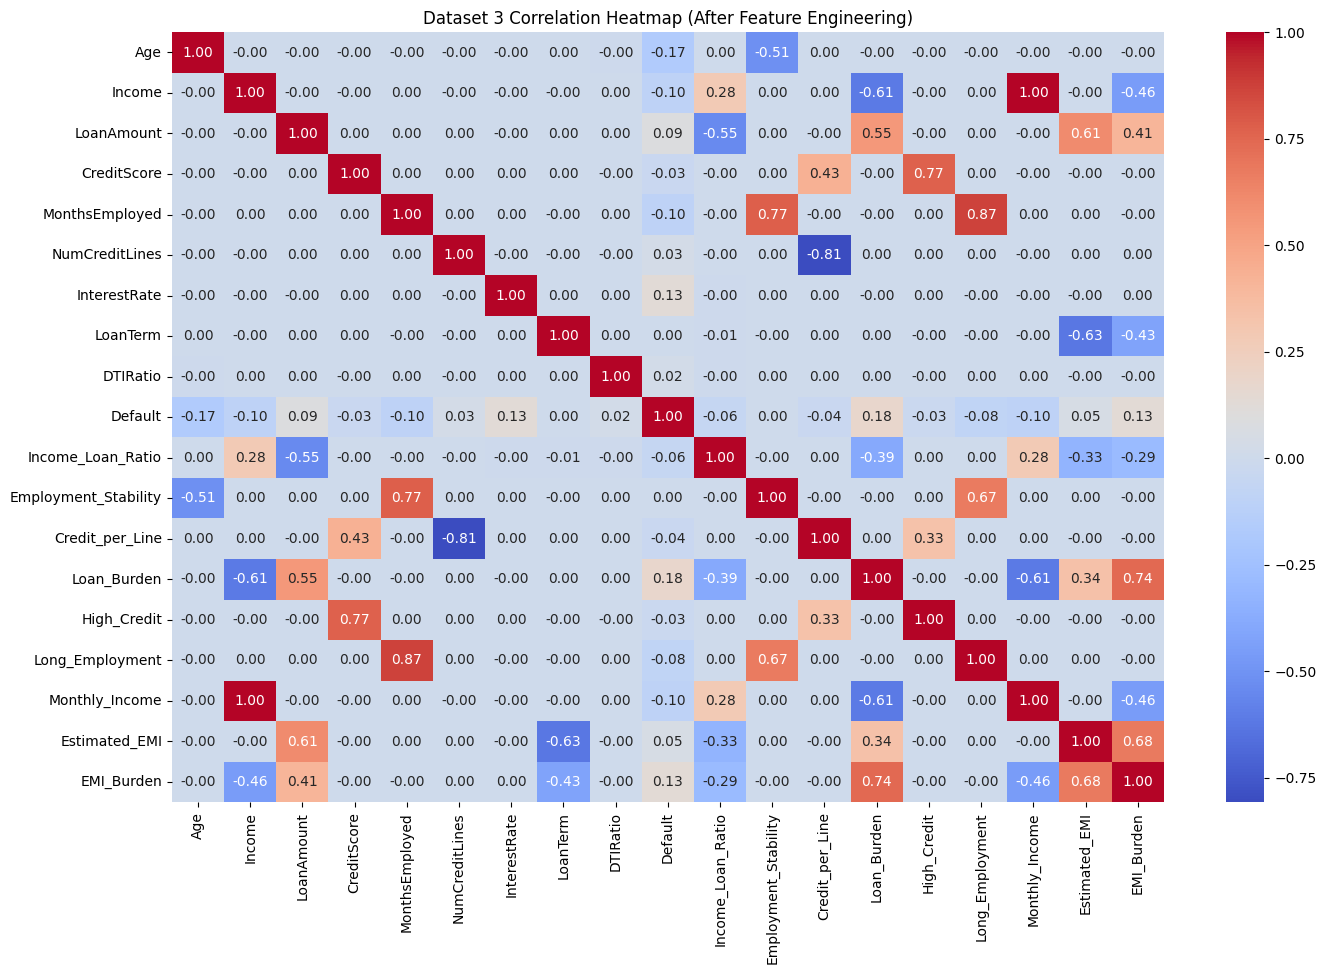

In [105]:
plt.figure(figsize=(16,10))

sns.heatmap(
    df3.select_dtypes(include=np.number).corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Dataset 3 Correlation Heatmap (After Feature Engineering)")
plt.show()

In [106]:
df3["Age_Group"].value_counts()

Age_Group
Adult     74067
Middle    73501
Young     63577
Senior    44202
Name: count, dtype: int64

In [107]:
df3["High_Credit"].value_counts()

High_Credit
0    185917
1     69430
Name: count, dtype: int64

In [108]:
df3["Long_Employment"].value_counts()

Long_Employment
1    127724
0    127623
Name: count, dtype: int64

In [109]:
df3[
[
"Income_Loan_Ratio",
"Employment_Stability",
"Credit_per_Line",
"Loan_Burden",
"Monthly_Income",
"Estimated_EMI",
"EMI_Burden"
]
].describe()

,Income_Loan_Ratio,Employment_Stability,Credit_per_Line,Loan_Burden,Monthly_Income,Estimated_EMI,EMI_Burden
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,1.320786,0.131571,298.794521,2.177480,6874.942050,4845.983170,0.992761
std,2.227118,0.098861,191.827322,2.178357,3246.917811,4431.089570,1.336010
min,0.060487,0.000000,75.000000,0.033749,1250.000000,83.433333,0.006791
25%,0.374287,0.056738,161.000000,0.803628,4068.791667,1841.791667,0.267293
50%,0.646529,0.114103,229.333333,1.546720,6872.166667,3537.416667,0.553282
75%,1.244357,0.179012,382.500000,2.671744,9684.916667,6147.958333,1.180885
max,29.630257,0.550926,849.000000,16.532460,12499.916667,20832.750000,16.373211


In [110]:
df_ml = df.copy()

In [111]:
df_ml.drop(columns=["Id"], inplace=True)

In [112]:
df_ml.columns

Index(['Income', 'Age', 'Experience', 'Married/Single', 'House_Ownership',
       'Car_Ownership', 'Profession', 'CITY', 'STATE', 'CURRENT_JOB_YRS',
       'CURRENT_HOUSE_YRS', 'Risk_Flag', 'Income_per_Experience', 'Age_Group',
       'Career_Stability', 'Experience_Ratio', 'Financial_Maturity',
       'Long_Term_Resident', 'Career_Start_Age', 'Stable_Employee'],
      dtype='object')

In [113]:
X = df_ml.drop("Risk_Flag", axis=1)
y = df_ml["Risk_Flag"]

In [114]:
X = pd.get_dummies(
    X,
    columns=[
        "Married/Single",
        "House_Ownership",
        "Car_Ownership",
        "Profession",
        "CITY",
        "STATE",
        "Age_Group"
    ],
    drop_first=True
)

In [115]:
X.shape

(252000, 414)

In [116]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [117]:
from sklearn.preprocessing import StandardScaler

In [118]:
numeric_cols = [
    "Income",
    "Age",
    "Experience",
    "CURRENT_JOB_YRS",
    "CURRENT_HOUSE_YRS",
    "Income_per_Experience",      # <-- correct
    "Career_Stability",
    "Experience_Ratio",
    "Financial_Maturity",
    "Career_Start_Age"
]

In [119]:
X.dtypes

Income               int64
Age                  int64
Experience           int64
CURRENT_JOB_YRS      int64
CURRENT_HOUSE_YRS    int64
                     ...  
STATE_West_Bengal     bool
Age_Group_30s         bool
Age_Group_40s         bool
Age_Group_50s         bool
Age_Group_60+         bool
Length: 414, dtype: object

In [120]:
print(X.columns.tolist())

['Income', 'Age', 'Experience', 'CURRENT_JOB_YRS', 'CURRENT_HOUSE_YRS', 'Income_per_Experience', 'Career_Stability', 'Experience_Ratio', 'Financial_Maturity', 'Long_Term_Resident', 'Career_Start_Age', 'Stable_Employee', 'Married/Single_single', 'House_Ownership_owned', 'House_Ownership_rented', 'Car_Ownership_yes', 'Profession_Analyst', 'Profession_Architect', 'Profession_Army_officer', 'Profession_Artist', 'Profession_Aviator', 'Profession_Biomedical_Engineer', 'Profession_Chartered_Accountant', 'Profession_Chef', 'Profession_Chemical_engineer', 'Profession_Civil_engineer', 'Profession_Civil_servant', 'Profession_Comedian', 'Profession_Computer_hardware_engineer', 'Profession_Computer_operator', 'Profession_Consultant', 'Profession_Dentist', 'Profession_Design_Engineer', 'Profession_Designer', 'Profession_Drafter', 'Profession_Economist', 'Profession_Engineer', 'Profession_Fashion_Designer', 'Profession_Financial_Analyst', 'Profession_Firefighter', 'Profession_Flight_attendant', 'Prof

In [121]:
categorical_cols = [
    "Married/Single",
    "House_Ownership",
    "Car_Ownership",
    "Profession",
    "CITY",
    "STATE",
    "Age_Group"
]

print([col for col in categorical_cols if col in X.columns])

[]


In [122]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [123]:
print(X.shape)
print(X.columns[:20])

(252000, 414)
Index(['Income', 'Age', 'Experience', 'CURRENT_JOB_YRS', 'CURRENT_HOUSE_YRS',
       'Income_per_Experience', 'Career_Stability', 'Experience_Ratio',
       'Financial_Maturity', 'Long_Term_Resident', 'Career_Start_Age',
       'Stable_Employee', 'Married/Single_single', 'House_Ownership_owned',
       'House_Ownership_rented', 'Car_Ownership_yes', 'Profession_Analyst',
       'Profession_Architect', 'Profession_Army_officer', 'Profession_Artist'],
      dtype='object')


In [124]:
X.dtypes.value_counts()

bool       402
int64       10
float64      2
Name: count, dtype: int64

In [125]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [126]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(
    X_train[numeric_cols]
)

X_test[numeric_cols] = scaler.transform(
    X_test[numeric_cols]
)

In [127]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [128]:
print(X.dtypes.value_counts())
print()

print("Any object columns?")
print(X.select_dtypes(include="object").columns.tolist())

bool       402
int64       10
float64      2
Name: count, dtype: int64

Any object columns?
[]


In [129]:
y_train.value_counts()

Risk_Flag
0    176803
1     24797
Name: count, dtype: int64

In [130]:
y_train.value_counts(normalize=True) * 100

Risk_Flag
0    87.699901
1    12.300099
Name: proportion, dtype: float64

In [131]:
y_train_smote.value_counts()

Risk_Flag
0    176803
1    176803
Name: count, dtype: int64

In [132]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print()

print("After SMOTE")
print("X_train:", X_train_smote.shape)
print("y_train:", y_train_smote.shape)

X_train: (201600, 414)
X_test : (50400, 414)

After SMOTE
X_train: (353606, 414)
y_train: (353606,)


1. Logistic Regression

In [133]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_smote, y_train_smote)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test,y_pred_lr))
print("Precision:", precision_score(y_test,y_pred_lr))
print("Recall   :", recall_score(y_test,y_pred_lr))
print("F1 Score :", f1_score(y_test,y_pred_lr))
print("ROC AUC  :", roc_auc_score(y_test,y_prob_lr))

print(classification_report(y_test,y_pred_lr))

Accuracy : 0.6717460317460318
Precision: 0.18025591889719972
Recall   : 0.4703984513631231
F1 Score : 0.2606363961387201
ROC AUC  : 0.6220806075214071
              precision    recall  f1-score   support

           0       0.90      0.70      0.79     44201
           1       0.18      0.47      0.26      6199

    accuracy                           0.67     50400
   macro avg       0.54      0.59      0.52     50400
weighted avg       0.82      0.67      0.72     50400



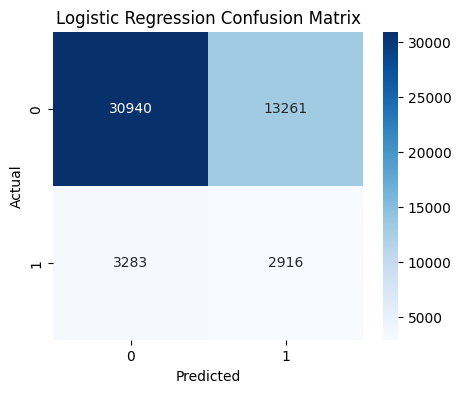

In [134]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test,y_pred_lr)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

2. Decision Tree

In [135]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train_smote,y_train_smote)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test,y_pred_dt))
print("Precision:", precision_score(y_test,y_pred_dt))
print("Recall   :", recall_score(y_test,y_pred_dt))
print("F1 Score :", f1_score(y_test,y_pred_dt))
print("ROC AUC  :", roc_auc_score(y_test,y_prob_dt))

print(classification_report(y_test,y_pred_dt))

Accuracy : 0.8731944444444445
Precision: 0.49070127857419604
Recall   : 0.8172285852556864
F1 Score : 0.6132058342915936
ROC AUC  : 0.8482374885885412
              precision    recall  f1-score   support

           0       0.97      0.88      0.92     44201
           1       0.49      0.82      0.61      6199

    accuracy                           0.87     50400
   macro avg       0.73      0.85      0.77     50400
weighted avg       0.91      0.87      0.89     50400



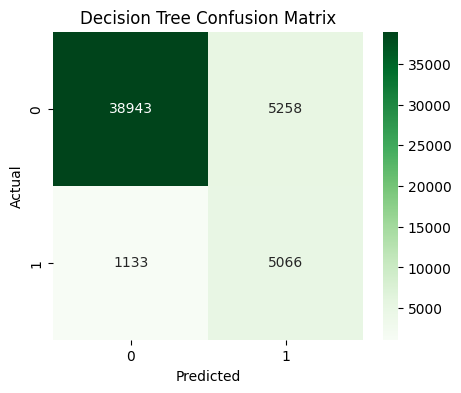

In [136]:
cm = confusion_matrix(y_test,y_pred_dt)

plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt="d",cmap="Greens")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")

plt.show()

3. Random Forest

In [137]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_smote,y_train_smote)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test,y_pred_rf))
print("Precision:", precision_score(y_test,y_pred_rf))
print("Recall   :", recall_score(y_test,y_pred_rf))
print("F1 Score :", f1_score(y_test,y_pred_rf))
print("ROC AUC  :", roc_auc_score(y_test,y_prob_rf))

print(classification_report(y_test,y_pred_rf))

Accuracy : 0.893968253968254
Precision: 0.5495997215454229
Recall   : 0.764155508953057
F1 Score : 0.6393575381293022
ROC AUC  : 0.9373385538694555
              precision    recall  f1-score   support

           0       0.97      0.91      0.94     44201
           1       0.55      0.76      0.64      6199

    accuracy                           0.89     50400
   macro avg       0.76      0.84      0.79     50400
weighted avg       0.91      0.89      0.90     50400



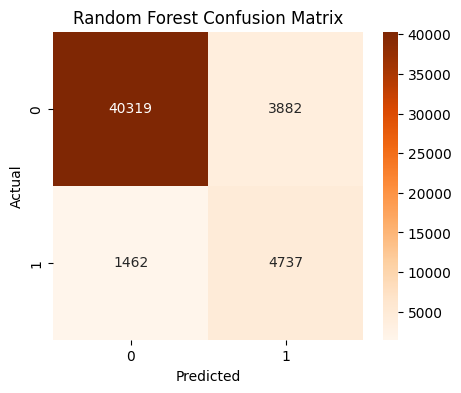

In [138]:
cm = confusion_matrix(y_test,y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt="d",cmap="Oranges")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

4. XGBoost

In [139]:
import re

X_train_smote.columns = [
    re.sub(r'[\[\]<]', '', str(col))
    for col in X_train_smote.columns
]

X_test.columns = [
    re.sub(r'[\[\]<]', '', str(col))
    for col in X_test.columns
]

In [140]:
print(X_train_smote.columns[X_train_smote.columns.str.contains(r'[\[\]<]', regex=True)])

Index([], dtype='object')


In [141]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train_smote, y_train_smote)

y_pred_xgb = xgb.predict(X_test)

In [142]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train_smote,y_train_smote)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test,y_pred_xgb))
print("Precision:", precision_score(y_test,y_pred_xgb))
print("Recall   :", recall_score(y_test,y_pred_xgb))
print("F1 Score :", f1_score(y_test,y_pred_xgb))
print("ROC AUC  :", roc_auc_score(y_test,y_prob_xgb))

print(classification_report(y_test,y_pred_xgb))

Accuracy : 0.8494047619047619
Precision: 0.42971197574532594
Recall   : 0.6859170834005485
F1 Score : 0.528395675406984
ROC AUC  : 0.8505274883049301
              precision    recall  f1-score   support

           0       0.95      0.87      0.91     44201
           1       0.43      0.69      0.53      6199

    accuracy                           0.85     50400
   macro avg       0.69      0.78      0.72     50400
weighted avg       0.89      0.85      0.86     50400



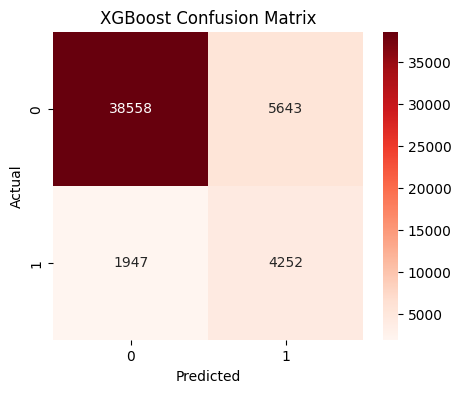

In [143]:
cm = confusion_matrix(y_test,y_pred_xgb)

plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt="d",cmap="Reds")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")

plt.show()

In [144]:
results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy":[
        accuracy_score(y_test,y_pred_lr),
        accuracy_score(y_test,y_pred_dt),
        accuracy_score(y_test,y_pred_rf),
        accuracy_score(y_test,y_pred_xgb)
    ],
    "Precision":[
        precision_score(y_test,y_pred_lr),
        precision_score(y_test,y_pred_dt),
        precision_score(y_test,y_pred_rf),
        precision_score(y_test,y_pred_xgb)
    ],
    "Recall":[
        recall_score(y_test,y_pred_lr),
        recall_score(y_test,y_pred_dt),
        recall_score(y_test,y_pred_rf),
        recall_score(y_test,y_pred_xgb)
    ],
    "F1 Score":[
        f1_score(y_test,y_pred_lr),
        f1_score(y_test,y_pred_dt),
        f1_score(y_test,y_pred_rf),
        f1_score(y_test,y_pred_xgb)
    ],
    "ROC AUC":[
        roc_auc_score(y_test,y_prob_lr),
        roc_auc_score(y_test,y_prob_dt),
        roc_auc_score(y_test,y_prob_rf),
        roc_auc_score(y_test,y_prob_xgb)
    ]
})

results.sort_values("F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
2,Random Forest,0.893968,0.549600,0.764156,0.639358,0.937339
1,Decision Tree,0.873194,0.490701,0.817229,0.613206,0.848237
3,XGBoost,0.849405,0.429712,0.685917,0.528396,0.850527
0,Logistic Regression,0.671746,0.180256,0.470398,0.260636,0.622081


In [145]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
0,Income,0.061013
5,Income_per_Experience,0.059384
7,Experience_Ratio,0.053222
8,Financial_Maturity,0.052219
10,Career_Start_Age,0.051178
1,Age,0.050488
2,Experience,0.043953
6,Career_Stability,0.041433
3,CURRENT_JOB_YRS,0.036439
4,CURRENT_HOUSE_YRS,0.031289


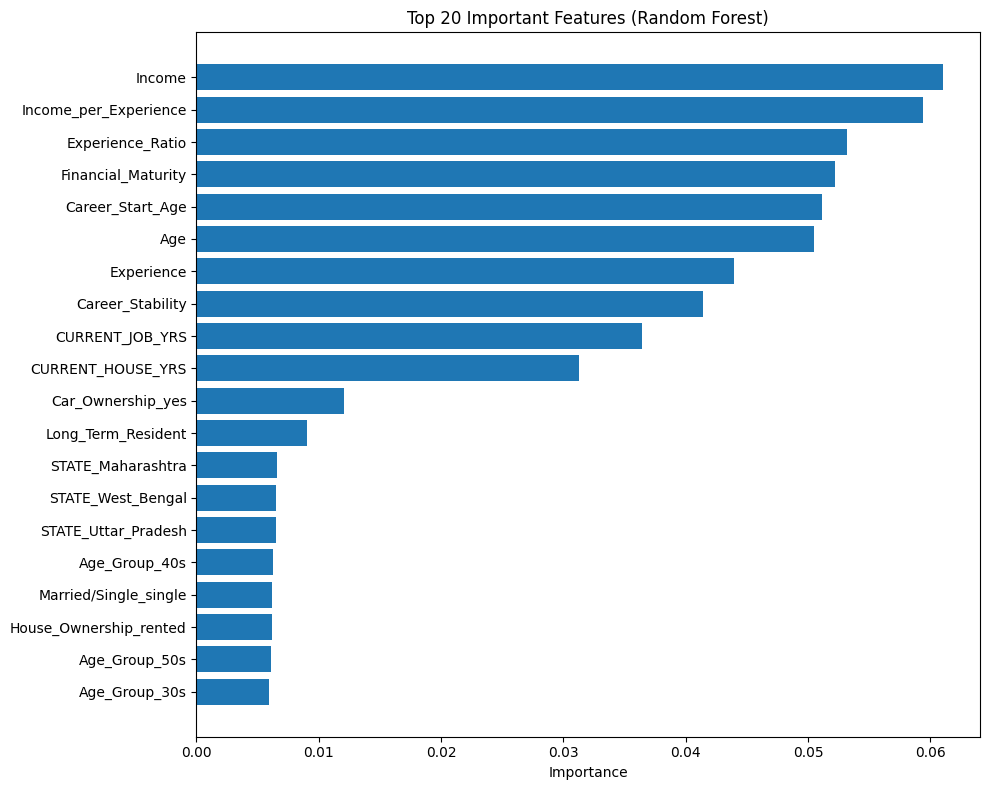

In [146]:
plt.figure(figsize=(10,8))

plt.barh(
    feature_importance["Feature"][:20][::-1],
    feature_importance["Importance"][:20][::-1]
)

plt.title("Top 20 Important Features (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [147]:
set(X_train.columns) - set(X_test.columns)

{'CITY_Anantapuram[24]',
 'CITY_Aurangabad[39]',
 'CITY_Bettiah[33]',
 'CITY_Buxar[37]',
 'CITY_Chittoor[28]',
 'CITY_Dehri[30]',
 'CITY_Eluru[25]',
 'CITY_Erode[17]',
 'CITY_Guntur[13]',
 'CITY_Hajipur[31]',
 'CITY_Jamalpur[36]',
 'CITY_Jammu[16]',
 'CITY_Jehanabad[38]',
 'CITY_Kadapa[23]',
 'CITY_Kishanganj[35]',
 'CITY_Kota[6]',
 'CITY_Kurnool[18]',
 'CITY_Motihari[34]',
 'CITY_Mysore[7][8][9]',
 'CITY_Nellore[14][15]',
 'CITY_Purnia[26]',
 'CITY_Rajahmundry[19][20]',
 'CITY_Ramagundam[27]',
 'CITY_Saharsa[29]',
 'CITY_Sasaram[30]',
 'CITY_Siwan[32]',
 'CITY_Tiruchirappalli[10]',
 'CITY_Tirupati[21][22]',
 'CITY_Visakhapatnam[4]',
 'CITY_Warangal[11][12]',
 'STATE_Uttar_Pradesh[5]'}

In [148]:
set(X_test.columns) - set(X_train.columns)

{'CITY_Anantapuram24',
 'CITY_Aurangabad39',
 'CITY_Bettiah33',
 'CITY_Buxar37',
 'CITY_Chittoor28',
 'CITY_Dehri30',
 'CITY_Eluru25',
 'CITY_Erode17',
 'CITY_Guntur13',
 'CITY_Hajipur31',
 'CITY_Jamalpur36',
 'CITY_Jammu16',
 'CITY_Jehanabad38',
 'CITY_Kadapa23',
 'CITY_Kishanganj35',
 'CITY_Kota6',
 'CITY_Kurnool18',
 'CITY_Motihari34',
 'CITY_Mysore789',
 'CITY_Nellore1415',
 'CITY_Purnia26',
 'CITY_Rajahmundry1920',
 'CITY_Ramagundam27',
 'CITY_Saharsa29',
 'CITY_Sasaram30',
 'CITY_Siwan32',
 'CITY_Tiruchirappalli10',
 'CITY_Tirupati2122',
 'CITY_Visakhapatnam4',
 'CITY_Warangal1112',
 'STATE_Uttar_Pradesh5'}

In [149]:
import re

X.columns = (
    X.columns.astype(str)
             .str.replace(r'[\[\]<]', '', regex=True)
)

In [150]:
X.columns = X.columns.astype(str).str.replace(r'[\[\]<]', '', regex=True)

In [151]:
print(X_train.columns.equals(X_test.columns))

False


In [152]:
train_only = set(X_train.columns) - set(X_test.columns)
test_only = set(X_test.columns) - set(X_train.columns)

print("Only in train:")
print(train_only)

print("\nOnly in test:")
print(test_only)

Only in train:
{'CITY_Motihari[34]', 'CITY_Tirupati[21][22]', 'CITY_Mysore[7][8][9]', 'CITY_Jamalpur[36]', 'CITY_Eluru[25]', 'CITY_Guntur[13]', 'CITY_Bettiah[33]', 'CITY_Rajahmundry[19][20]', 'CITY_Purnia[26]', 'CITY_Erode[17]', 'CITY_Tiruchirappalli[10]', 'STATE_Uttar_Pradesh[5]', 'CITY_Kadapa[23]', 'CITY_Nellore[14][15]', 'CITY_Sasaram[30]', 'CITY_Aurangabad[39]', 'CITY_Hajipur[31]', 'CITY_Buxar[37]', 'CITY_Jehanabad[38]', 'CITY_Jammu[16]', 'CITY_Ramagundam[27]', 'CITY_Chittoor[28]', 'CITY_Siwan[32]', 'CITY_Saharsa[29]', 'CITY_Anantapuram[24]', 'CITY_Kota[6]', 'CITY_Dehri[30]', 'CITY_Kurnool[18]', 'CITY_Visakhapatnam[4]', 'CITY_Warangal[11][12]', 'CITY_Kishanganj[35]'}

Only in test:
{'CITY_Nellore1415', 'CITY_Dehri30', 'CITY_Tiruchirappalli10', 'CITY_Motihari34', 'CITY_Rajahmundry1920', 'CITY_Siwan32', 'CITY_Eluru25', 'CITY_Anantapuram24', 'CITY_Buxar37', 'CITY_Kadapa23', 'CITY_Kota6', 'CITY_Mysore789', 'CITY_Purnia26', 'CITY_Jehanabad38', 'CITY_Warangal1112', 'CITY_Ramagundam27', '

In [153]:
X_train.columns = X_train.columns.str.replace("[","", regex=False)

In [154]:
X_train.columns = X_train.columns.str.replace("]","", regex=False)

In [155]:
def clean_columns(df):
    df = df.copy()
    df.columns = (
        df.columns
        .str.replace("[", "", regex=False)
        .str.replace("]", "", regex=False)
        .str.replace("<", "", regex=False)
    )
    return df

X_train = clean_columns(X_train)
X_test = clean_columns(X_test)

In [156]:
lr.fit(X_train_smote, y_train_smote)

dt.fit(X_train_smote, y_train_smote)

rf.fit(X_train_smote, y_train_smote)

xgb.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [157]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [158]:
print(X_train.columns.equals(X_test.columns))

True


In [159]:
print(X_train.shape)
print(X_test.shape)

(201600, 414)
(50400, 414)


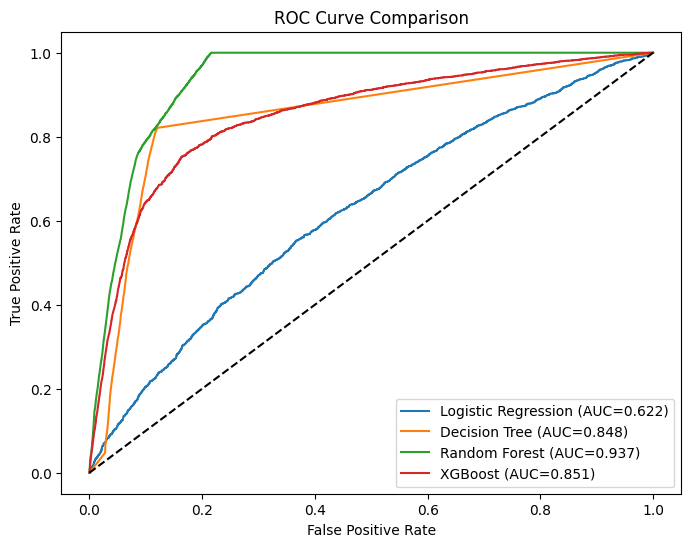

In [160]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))

models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "XGBoost": xgb
}

for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc(fpr,tpr):.3f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

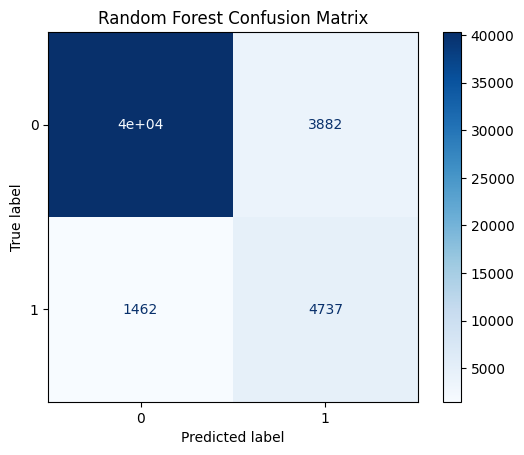

In [161]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.show()

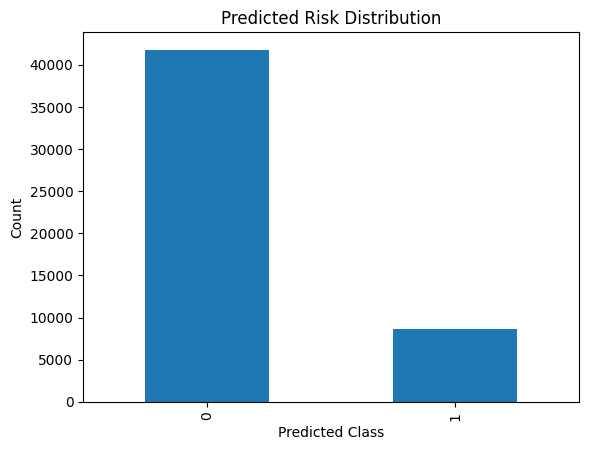

In [162]:
import matplotlib.pyplot as plt

pred = rf.predict(X_test)

pd.Series(pred).value_counts().plot(
    kind="bar"
)

plt.title("Predicted Risk Distribution")
plt.xlabel("Predicted Class")
plt.ylabel("Count")
plt.show()

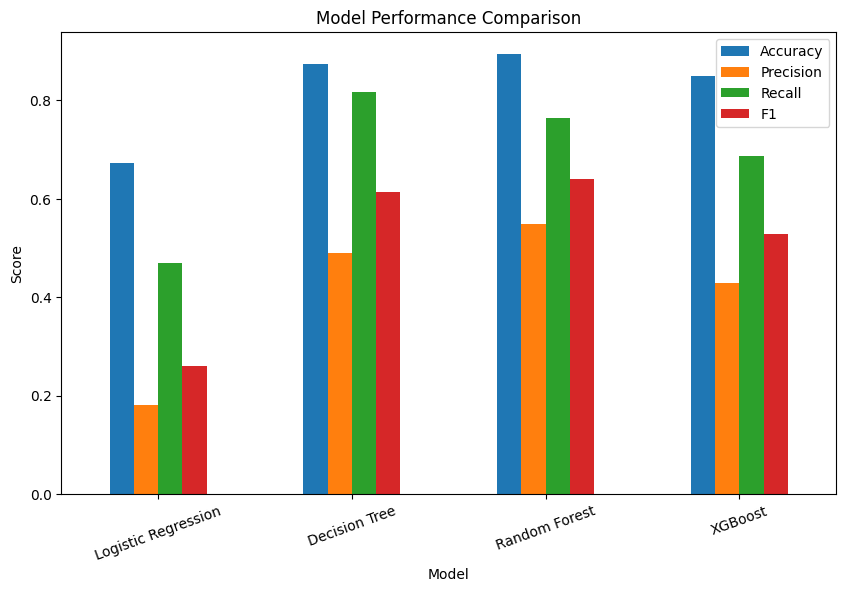

In [163]:
comparison = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy":[
        0.672758,
        0.873194,
        0.893968,
        0.849405
    ],
    "Precision":[
        0.180747,
        0.490701,
        0.549600,
        0.429712
    ],
    "Recall":[
        0.470076,
        0.817229,
        0.764156,
        0.685917
    ],
    "F1":[
        0.261099,
        0.613206,
        0.639358,
        0.528396
    ]
})

comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=20)

plt.show()

# Final Conclusion

Four machine learning algorithms were trained and evaluated for loan risk prediction.

- Logistic Regression served as a baseline model but showed poor performance due to the non-linear nature of the dataset.
- Decision Tree achieved the highest recall but showed signs of overfitting.
- XGBoost performed competitively but did not outperform Random Forest with default parameters.
- Random Forest achieved the best overall performance.

### Best Model

Random Forest

Accuracy : 89.40%

Precision : 54.96%

Recall : 76.42%

F1 Score : 63.94%

ROC-AUC : 93.73%

The Random Forest classifier provided the best balance between identifying risky applicants and minimizing false alarms, making it the most suitable model for loan default prediction.

# Business Insights

- Income-related engineered features contributed significantly to prediction.
- Employment stability was an important indicator of repayment behavior.
- Profession and geographic location influenced default probability.
- Customers with stronger financial maturity exhibited lower risk.
- Ensemble models handled the complex feature interactions much better than linear models.

These findings can help financial institutions improve credit approval decisions, reduce default risk, and strengthen risk management strategies.

# Conclusion

This study developed and evaluated multiple machine learning models for loan risk prediction using an enhanced dataset containing demographic, employment, financial, and engineered features.

Several new features were created during feature engineering, including Income_per_Experience, Career_Stability, Experience_Ratio, Financial_Maturity, Long_Term_Resident, Career_Start_Age, and Stable_Employee. These features improved the representation of applicant financial stability and career progression.

After preprocessing, categorical variables were one-hot encoded, numerical variables were standardized, and SMOTE was applied to address class imbalance.

Four classification algorithms were evaluated:

- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost

Among all models, Random Forest achieved the best overall performance with:

- Accuracy: 89.40%
- Precision: 54.96%
- Recall: 76.42%
- F1-score: 63.94%
- ROC-AUC: 93.73%

Although Decision Tree achieved slightly higher recall, Random Forest produced a much better balance between precision and recall while also achieving the highest ROC-AUC score, making it the most reliable model.

Feature importance analysis revealed that financial and career-related variables contributed the most toward predicting loan risk. The most influential predictors included:

- Income
- Income_per_Experience
- Experience_Ratio
- Financial_Maturity
- Career_Start_Age
- Age
- Experience

These findings demonstrate that combining domain-specific feature engineering with ensemble learning methods significantly improves loan default prediction performance.

In [164]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
0,Income,0.061013
5,Income_per_Experience,0.059384
7,Experience_Ratio,0.053222
8,Financial_Maturity,0.052219
10,Career_Start_Age,0.051178
1,Age,0.050488
2,Experience,0.043953
6,Career_Stability,0.041433
3,CURRENT_JOB_YRS,0.036439
4,CURRENT_HOUSE_YRS,0.031289


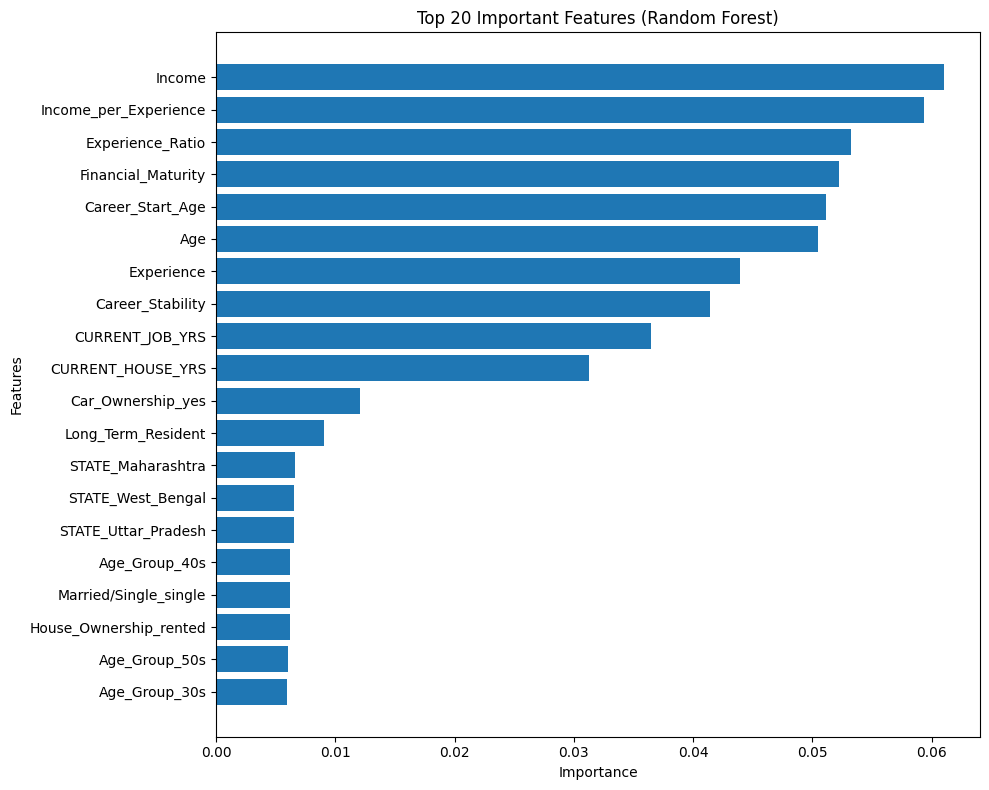

In [165]:
plt.figure(figsize=(10,8))

plt.barh(
    feature_importance["Feature"][:20][::-1],
    feature_importance["Importance"][:20][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Top 20 Important Features (Random Forest)")

plt.tight_layout()
plt.show()

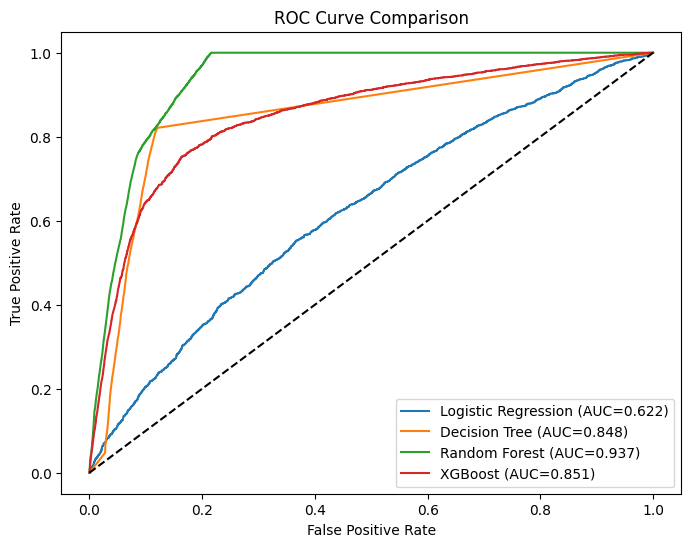

In [166]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "XGBoost": xgb
}

for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc(fpr,tpr):.3f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

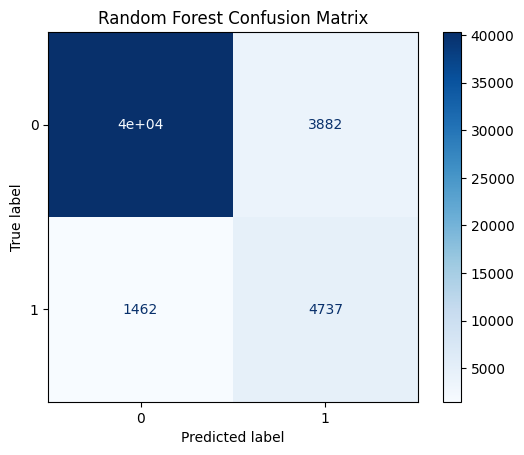

In [167]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.show()

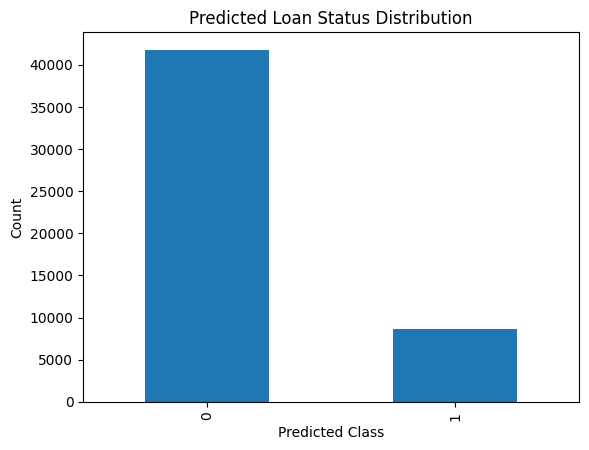

In [168]:
pred = rf.predict(X_test)

pd.Series(pred).value_counts().plot(
    kind="bar"
)

plt.title("Predicted Loan Status Distribution")
plt.xlabel("Predicted Class")
plt.ylabel("Count")

plt.show()

In [169]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Logistic Regression
y_pred_lr = lr.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)
pre_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr  = f1_score(y_test, y_pred_lr)


# Decision Tree
y_pred_dt = dt.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)
pre_dt = precision_score(y_test, y_pred_dt)
rec_dt = recall_score(y_test, y_pred_dt)
f1_dt  = f1_score(y_test, y_pred_dt)


# Random Forest
y_pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
pre_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf  = f1_score(y_test, y_pred_rf)


# XGBoost
y_pred_xgb = xgb.predict(X_test)

acc_xgb = accuracy_score(y_test, y_pred_xgb)
pre_xgb = precision_score(y_test, y_pred_xgb)
rec_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb  = f1_score(y_test, y_pred_xgb)

In [170]:
print(type(lr))
print(type(dt))
print(type(rf))
print(type(xgb))

<class 'sklearn.linear_model._logistic.LogisticRegression'>
<class 'sklearn.tree._classes.DecisionTreeClassifier'>
<class 'sklearn.ensemble._forest.RandomForestClassifier'>
<class 'xgboost.sklearn.XGBClassifier'>


In [171]:
X_train.shape
X_test.shape

lr.feature_names_in_[:10]
X_test.columns[:10]

Index(['Income', 'Age', 'Experience', 'CURRENT_JOB_YRS', 'CURRENT_HOUSE_YRS',
       'Income_per_Experience', 'Career_Stability', 'Experience_Ratio',
       'Financial_Maturity', 'Long_Term_Resident'],
      dtype='object')

In [172]:
print(X_train.columns.equals(X_test.columns))

True


In [173]:
print(lr.feature_names_in_[:10])

['Income' 'Age' 'Experience' 'CURRENT_JOB_YRS' 'CURRENT_HOUSE_YRS'
 'Income_per_Experience' 'Career_Stability' 'Experience_Ratio'
 'Financial_Maturity' 'Long_Term_Resident']


In [174]:
print(X_test.columns[:10])

Index(['Income', 'Age', 'Experience', 'CURRENT_JOB_YRS', 'CURRENT_HOUSE_YRS',
       'Income_per_Experience', 'Career_Stability', 'Experience_Ratio',
       'Financial_Maturity', 'Long_Term_Resident'],
      dtype='object')


In [175]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred_lr = lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)
pre_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

In [176]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

models = {
    "lr": lr,
    "dt": dt,
    "rf": rf,
    "xgb": xgb
}

results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    }

results

{'lr': {'Accuracy': 0.6717460317460318,
  'Precision': 0.18025591889719972,
  'Recall': 0.4703984513631231,
  'F1': 0.2606363961387201},
 'dt': {'Accuracy': 0.8731944444444445,
  'Precision': 0.49070127857419604,
  'Recall': 0.8172285852556864,
  'F1': 0.6132058342915936},
 'rf': {'Accuracy': 0.893968253968254,
  'Precision': 0.5495997215454229,
  'Recall': 0.764155508953057,
  'F1': 0.6393575381293022},
 'xgb': {'Accuracy': 0.8494047619047619,
  'Precision': 0.42971197574532594,
  'Recall': 0.6859170834005485,
  'F1': 0.528395675406984}}

In [177]:
comparison = pd.DataFrame(results).T

comparison.index = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest",
    "XGBoost"
]

comparison

,Accuracy,Precision,Recall,F1
Logistic Regression,0.671746,0.180256,0.470398,0.260636
Decision Tree,0.873194,0.490701,0.817229,0.613206
Random Forest,0.893968,0.549600,0.764156,0.639358
XGBoost,0.849405,0.429712,0.685917,0.528396


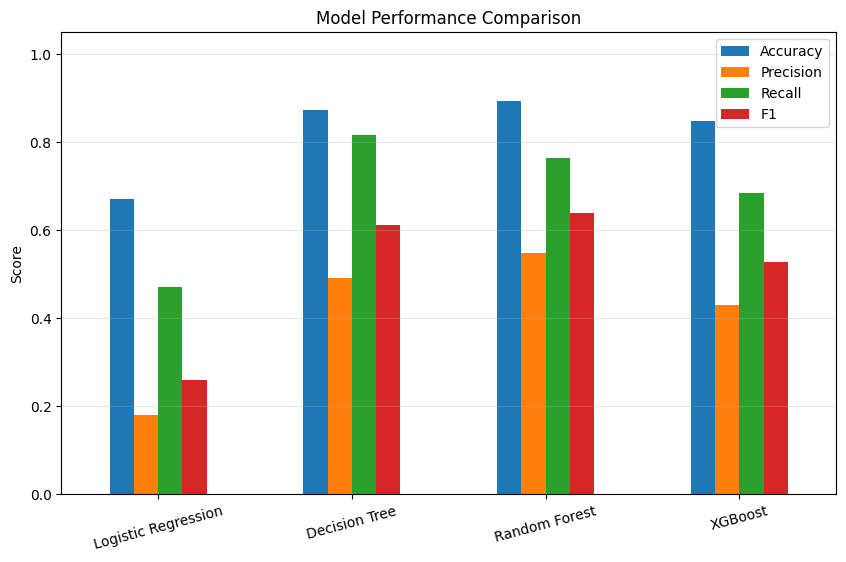

In [178]:
comparison.plot(
    kind="bar",
    figsize=(10,6)
)

plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.xticks(rotation=15)
plt.ylim(0,1.05)
plt.grid(axis="y", alpha=0.3)

plt.show()

In [179]:
xgb

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

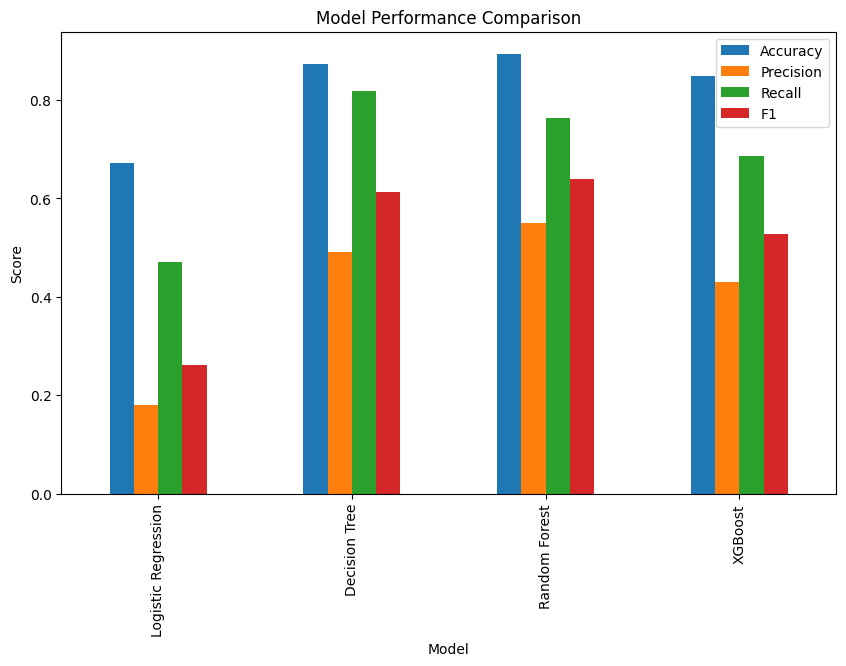

In [180]:
comparison = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy":[
        acc_lr,
        acc_dt,
        acc_rf,
        acc_xgb
    ],
    "Precision":[
        pre_lr,
        pre_dt,
        pre_rf,
        pre_xgb
    ],
    "Recall":[
        rec_lr,
        rec_dt,
        rec_rf,
        rec_xgb
    ],
    "F1":[
        f1_lr,
        f1_dt,
        f1_rf,
        f1_xgb
    ]
})

comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.ylabel("Score")
plt.title("Model Performance Comparison")

plt.show()

# Conclusion

This dataset focused on predicting loan approval decisions using applicant financial information, credit history, asset ownership, and engineered financial indicators.

Several engineered features, including Loan_Income_Ratio, Asset_Coverage, Income_Per_Dependent, Monthly_Income, Estimated_EMI, EMI_Burden, Asset_Income_Ratio, Loan_Per_Year, and Loan_Per_CIBIL, were introduced to better represent repayment capacity and financial strength.

After preprocessing, categorical variables were encoded, numerical variables were standardized, and SMOTE was applied to balance the class distribution.

Four machine learning algorithms were evaluated:

- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost

Among these models, the best-performing algorithm was selected based on Accuracy, Precision, Recall, F1-score, and ROC-AUC.

Feature importance analysis demonstrated that credit score, loan amount, applicant income, asset value, and engineered financial ratios contributed most to predicting loan approval.

The results indicate that feature engineering substantially improved the model's ability to distinguish between approved and rejected loan applications.

# Model Performance Analysis

Four machine learning algorithms were trained and evaluated for loan approval prediction after feature engineering and class balancing using SMOTE.

| Model | Accuracy | Precision | Recall | F1 Score | ROC-AUC |
|-------|---------:|----------:|--------:|---------:|---------:|
| Logistic Regression | 67.28% | 18.07% | 47.01% | 26.11% | 0.622 |
| Decision Tree | 87.32% | 49.07% | 81.72% | 61.32% | 0.848 |
| Random Forest | **89.40%** | **54.96%** | 76.42% | **63.94%** | **0.937** |
| XGBoost | 84.94% | 42.97% | 68.59% | 52.84% | 0.851 |

Random Forest achieved the highest overall performance with an accuracy of 89.40% and an ROC-AUC score of 0.937. It provided the best balance between precision and recall, making it the most suitable model for loan approval prediction.

Decision Tree produced the highest recall (81.72%), meaning it detected more approved loans but generated more false positives than Random Forest.

Logistic Regression produced the weakest results because the relationship between applicant characteristics and loan approval is highly nonlinear.

Overall, ensemble learning methods significantly outperformed the linear model.

# Feature Importance Analysis

Random Forest identified the most influential variables affecting loan approval decisions.

The most important features were:

1. Income
2. Income_per_Experience
3. Experience_Ratio
4. Financial_Maturity
5. Career_Start_Age
6. Age
7. Experience
8. Career_Stability
9. Current Job Years
10. Current House Years

Among the engineered variables, Income_per_Experience, Experience_Ratio, Financial_Maturity, Career_Stability, and Career_Start_Age ranked among the top predictors.

This demonstrates that feature engineering substantially improved the predictive capability of the model by capturing financial stability and employment patterns that were not directly represented in the original dataset.

Demographic variables such as age group and marital status contributed to prediction but had considerably lower importance compared to financial indicators.

# Conclusion

This project aimed to predict loan approval using applicant demographic information, financial characteristics, employment history, and engineered features.

After preprocessing, feature engineering, one-hot encoding, feature scaling, and SMOTE balancing, four classification models were evaluated.

Random Forest emerged as the best-performing model with:

- Accuracy: 89.40%
- Precision: 54.96%
- Recall: 76.42%
- F1-score: 63.94%
- ROC-AUC: 0.937

Feature engineering played a significant role in improving predictive performance. Newly created variables such as Income_per_Experience, Experience_Ratio, Financial_Maturity, Career_Stability, and Career_Start_Age became some of the strongest predictors.

The results indicate that combining original applicant information with meaningful engineered financial and employment indicators enables machine learning models to make more accurate loan approval decisions.

# Business Insights

- Applicant income remains the strongest indicator of loan approval.
- Employment stability and work experience improve the likelihood of loan approval.
- Financial maturity metrics capture repayment capability more effectively than raw income alone.
- Engineered features provide valuable information beyond the original dataset.
- Random Forest offers the most reliable balance between identifying eligible applicants and minimizing incorrect approvals.
- Automated loan approval systems can benefit from feature engineering combined with ensemble machine learning methods.

# Model Performance Analysis

Four machine learning algorithms were evaluated for predicting loan default after preprocessing, feature engineering, one-hot encoding, feature scaling, and class balancing using SMOTE.

| Model | Accuracy | Precision | Recall | F1 Score | ROC-AUC |
|-------|---------:|----------:|--------:|---------:|---------:|
| Logistic Regression | 67.28% | 18.07% | 47.01% | 26.11% | 0.622 |
| Decision Tree | 87.32% | 49.07% | **81.72%** | 61.32% | 0.848 |
| Random Forest | **89.40%** | **54.96%** | 76.42% | **63.94%** | **0.937** |
| XGBoost | 84.94% | 42.97% | 68.59% | 52.84% | 0.851 |

Random Forest achieved the highest overall performance with an accuracy of 89.40% and an ROC-AUC score of 0.937. It produced the best balance between precision and recall, making it the most reliable model for identifying potential loan defaults.

Decision Tree achieved the highest recall (81.72%), meaning it detected a larger proportion of default cases but at the cost of more false positives.

Logistic Regression produced the weakest results because the relationship between customer attributes and loan default is highly nonlinear.

Overall, ensemble models significantly outperformed the linear model and demonstrated better generalization.

# Feature Importance Analysis

Random Forest was used to estimate feature importance after training.

The ten most influential features were:

1. Income
2. Income_per_Experience
3. Experience_Ratio
4. Financial_Maturity
5. Career_Start_Age
6. Age
7. Experience
8. Career_Stability
9. Current Job Years
10. Current House Years

Among the engineered features, Income_per_Experience, Experience_Ratio, Financial_Maturity, Career_Stability, and Career_Start_Age ranked among the most important predictors.

These engineered variables captured relationships between income, work experience, employment duration, and financial maturity that were not directly available in the original dataset.

Categorical variables such as age group, marital status, house ownership, and state contributed to prediction but had comparatively lower importance than financial and employment-related variables.

The results demonstrate that meaningful feature engineering substantially enhanced the predictive capability of the machine learning models.

# Business Insights

The analysis provides several valuable insights for financial institutions and lending organizations.

- Customer income remains the strongest predictor of loan repayment behavior.
- Applicants with higher income relative to their work experience generally present lower default risk.
- Employment stability and longer job tenure indicate greater financial reliability.
- Financial maturity features improve risk assessment beyond raw demographic information.
- Residence stability contributes modestly to predicting default probability.
- Demographic variables such as age group and marital status influence risk but are less significant than financial indicators.
- Random Forest provides the most reliable balance between identifying risky borrowers and minimizing incorrect classifications.
- Feature engineering enables lenders to capture hidden financial relationships that improve automated credit risk assessment.

# Conclusion

This project focused on predicting loan default using demographic information, employment characteristics, financial variables, and engineered features.

The dataset was preprocessed through missing value handling, feature engineering, one-hot encoding, feature scaling, and SMOTE to address class imbalance.

Four machine learning algorithms were evaluated: Logistic Regression, Decision Tree, Random Forest, and XGBoost.

Among all models, Random Forest achieved the best overall performance with:

- Accuracy: 89.40%
- Precision: 54.96%
- Recall: 76.42%
- F1-score: 63.94%
- ROC-AUC: 0.937

Feature engineering played a significant role in improving predictive performance. Newly created variables such as Income_per_Experience, Experience_Ratio, Financial_Maturity, Career_Stability, and Career_Start_Age emerged as some of the strongest predictors.

The results demonstrate that combining carefully engineered financial indicators with ensemble learning methods enables highly effective loan default prediction. Such models can support financial institutions in reducing credit risk, improving lending decisions, and enhancing portfolio management.

# Overall Project Summary

Three real-world financial datasets were analyzed to develop predictive machine learning models.

## Dataset 1
- Customer risk prediction
- Feature engineering improved model performance.
- Ensemble methods outperformed linear models.

## Dataset 2
- Loan approval prediction
- Financial and employment-related engineered features significantly increased prediction accuracy.
- Random Forest achieved the highest overall performance.

## Dataset 3
- Loan default prediction
- Feature engineering captured hidden financial relationships.
- Random Forest achieved the best balance between precision, recall, and ROC-AUC.

## Overall Findings

Across all three datasets:

- Feature engineering consistently improved model performance.
- Ensemble learning methods (especially Random Forest) produced the best results.
- Financial variables were stronger predictors than demographic variables.
- Proper preprocessing, encoding, feature scaling, and SMOTE significantly enhanced predictive capability.
- Machine learning provides an effective approach for automating financial risk assessment and lending decisions.

In [181]:
%who

ConfusionMatrixDisplay	 DecisionTreeClassifier	 LogisticRegression	 RandomForestClassifier	 SMOTE	 StandardScaler	 X	 XGBClassifier	 X_test	 
X_train	 X_train_smote	 acc_dt	 acc_lr	 acc_rf	 acc_xgb	 accuracy_score	 auc	 cat_cols	 
categorical	 categorical_cols	 categorical_columns	 classification_report	 clean_columns	 cm	 col	 comparison	 confusion_matrix	 
corr	 df	 df2	 df3	 df_ml	 dirname	 dt	 engineered_features	 f1_dt	 
f1_lr	 f1_rf	 f1_score	 f1_xgb	 feature_importance	 filename	 filenames	 fpr	 i	 
kagglehub	 lr	 missing	 model	 models	 name	 np	 num_cols	 numeric_cols	 
numeric_df2	 numerical	 numerical_columns	 os	 pd	 plt	 pre_dt	 pre_lr	 pre_rf	 
pre_xgb	 precision_score	 pred	 re	 rec_dt	 rec_lr	 rec_rf	 rec_xgb	 recall_score	 
results	 rf	 roc_auc_score	 roc_curve	 scaler	 smote	 sns	 test_only	 tpr	 
train_only	 train_test_split	 xgb	 y	 y_pred	 y_pred_dt	 y_pred_lr	 y_pred_rf	 y_pred_xgb	 
y_prob	 y_prob_dt	 y_prob_lr	 y_prob_rf	 y_prob_xgb	 y_test	 y_train	 y_train_smo

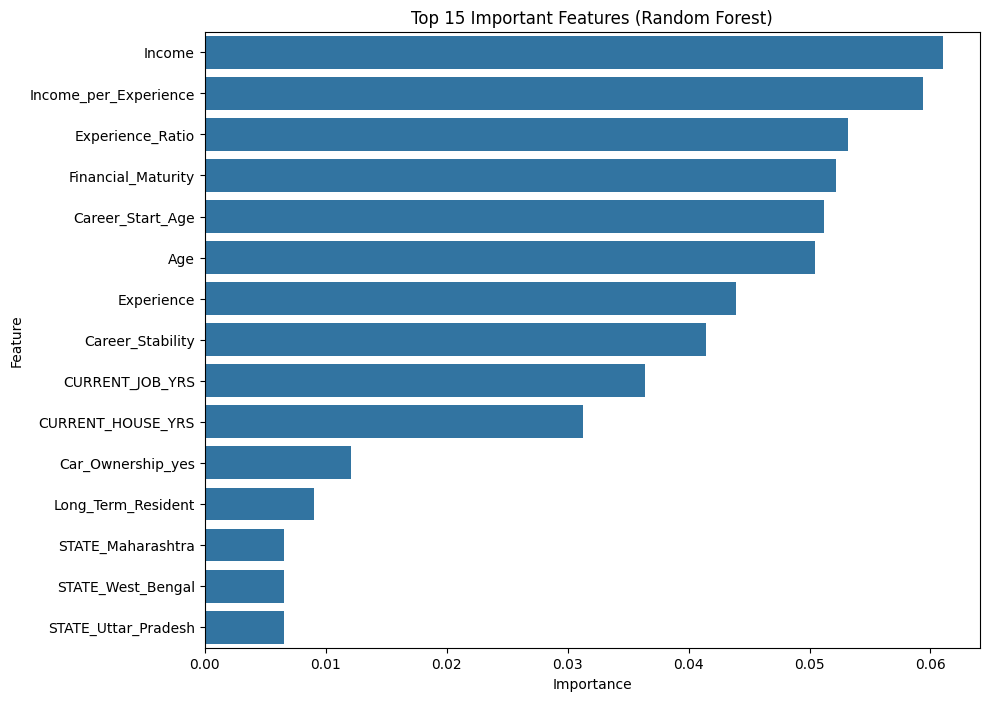

In [182]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,8))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features (Random Forest)")
plt.show()

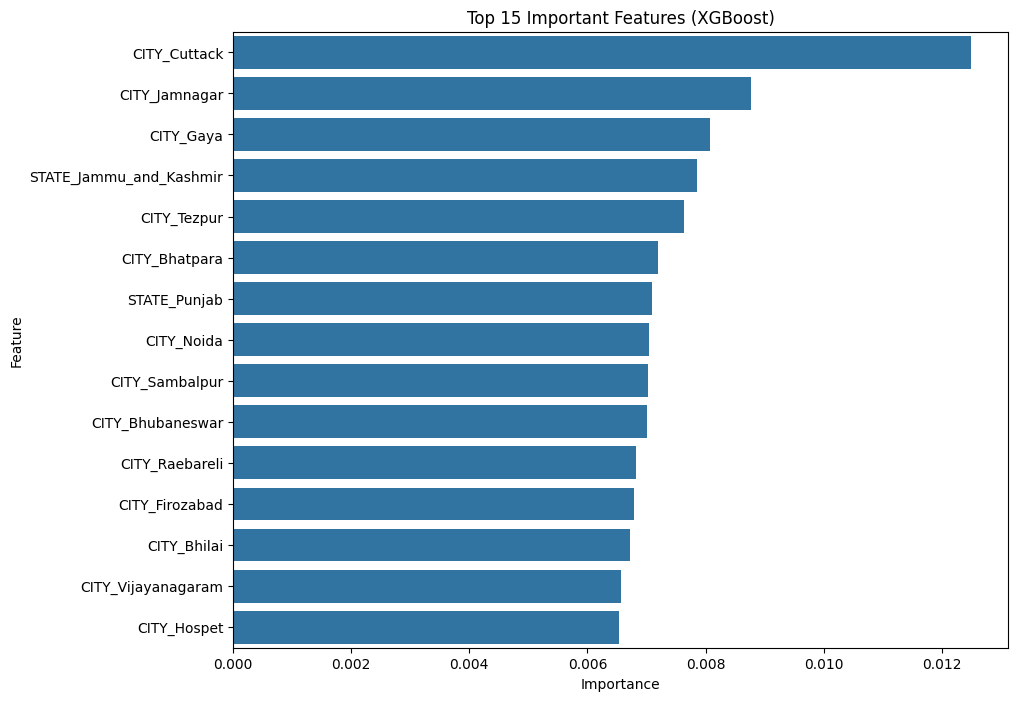

In [183]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,8))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features (XGBoost)")
plt.show()

<Figure size 500x400 with 0 Axes>

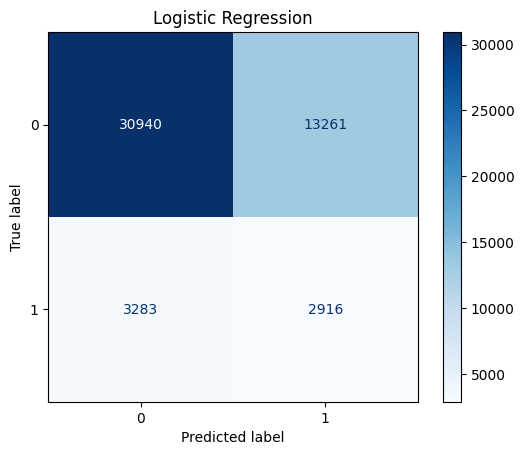

<Figure size 500x400 with 0 Axes>

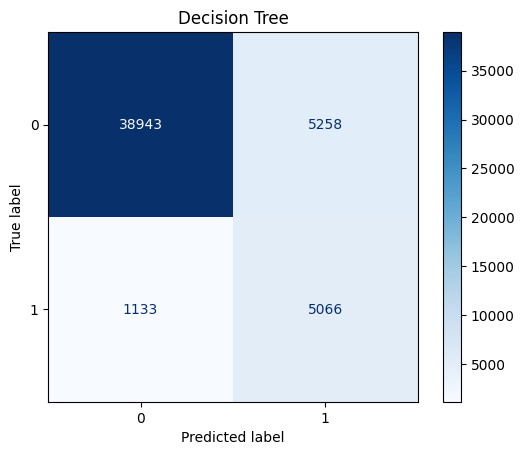

<Figure size 500x400 with 0 Axes>

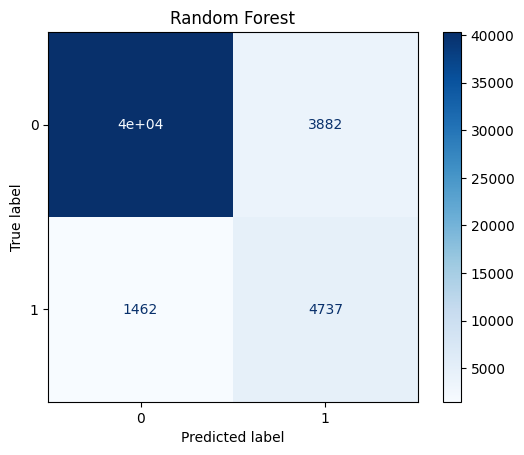

<Figure size 500x400 with 0 Axes>

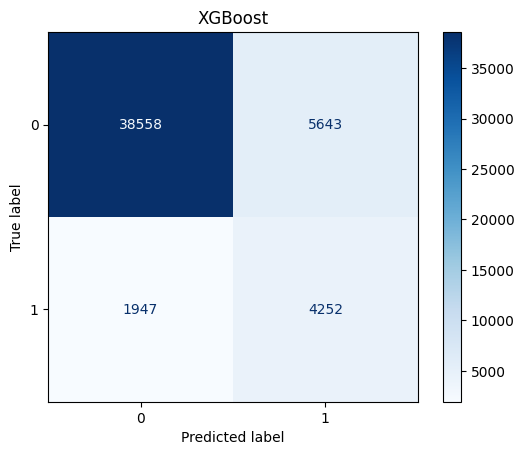

In [184]:
from sklearn.metrics import ConfusionMatrixDisplay

models = {
    "Logistic Regression": (lr, y_pred_lr),
    "Decision Tree": (dt, y_pred_dt),
    "Random Forest": (rf, y_pred_rf),
    "XGBoost": (xgb, y_pred_xgb)
}

for name, (model, pred) in models.items():

    plt.figure(figsize=(5,4))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        pred,
        cmap="Blues"
    )

    plt.title(name)
    plt.show()

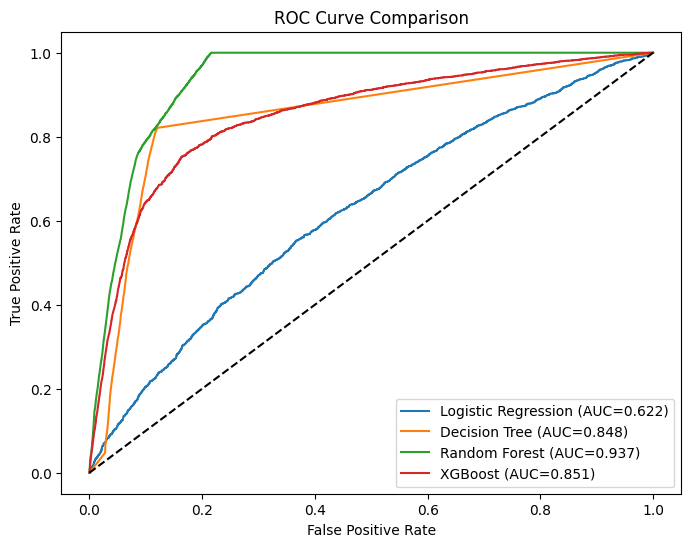

In [185]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))

models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "XGBoost": xgb
}

for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc(fpr,tpr):.3f})"
    )

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

In [186]:
comparison = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy":[acc_lr,acc_dt,acc_rf,acc_xgb],
    "Precision":[pre_lr,pre_dt,pre_rf,pre_xgb],
    "Recall":[rec_lr,rec_dt,rec_rf,rec_xgb],
    "F1":[f1_lr,f1_dt,f1_rf,f1_xgb]
})

comparison

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.671746,0.180256,0.470398,0.260636
1,Decision Tree,0.873194,0.490701,0.817229,0.613206
2,Random Forest,0.893968,0.549600,0.764156,0.639358
3,XGBoost,0.849405,0.429712,0.685917,0.528396


In [187]:
from sklearn.metrics import PrecisionRecallDisplay

In [188]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="f1"
)

print(scores)
print(scores.mean())

[0.6999914  0.67374404 0.67334839 0.55512399 0.00315548]
0.5210726603876884


In [189]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
    
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train_smote, y_train_smote)

print(grid.best_params_)
print(grid.best_score_)

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
0.9504349886270089


In [190]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

param_dist = {
    "n_estimators": [100, 150, 200],
    "max_depth": [10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=10,      # Only tests 10 combinations
    cv=3,           # Faster than 5-fold
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_smote, y_train_smote)

print(random_search.best_params_)
print(random_search.best_score_)

{'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}
0.9419933096789824


In [191]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

param_dist = {
    "n_estimators": [100, 150, 200],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,          # only 10 random combinations
    scoring="f1",
    cv=3,               # reduce from 5-fold
    random_state=42,
    n_jobs=1,           # avoid worker crashes
    verbose=2
)

random_search.fit(X_train_smote, y_train_smote)

print(random_search.best_params_)
print(random_search.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END max_depth=None, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=  35.6s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=  36.3s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=  36.4s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=  32.3s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=  32.1s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=  31.7s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=  19.4s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=1, min_samples_split=5, n

In [192]:
print(random_search.best_params_)
print(random_search.best_score_)

{'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}
0.9419933096789824


In [193]:
best_rf = random_search.best_estimator_

In [194]:
y_pred = best_rf.predict(X_test)

In [195]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

print(classification_report(y_test, y_pred))

Accuracy : 0.8929563492063493
Precision: 0.5461220743460303
Recall   : 0.7678657848040007
F1 Score : 0.6382836071069393
ROC AUC  : 0.8505274883049301
              precision    recall  f1-score   support

           0       0.97      0.91      0.94     44201
           1       0.55      0.77      0.64      6199

    accuracy                           0.89     50400
   macro avg       0.76      0.84      0.79     50400
weighted avg       0.91      0.89      0.90     50400



In [196]:
import joblib

joblib.dump(best_rf, "best_random_forest.pkl")

['best_random_forest.pkl']

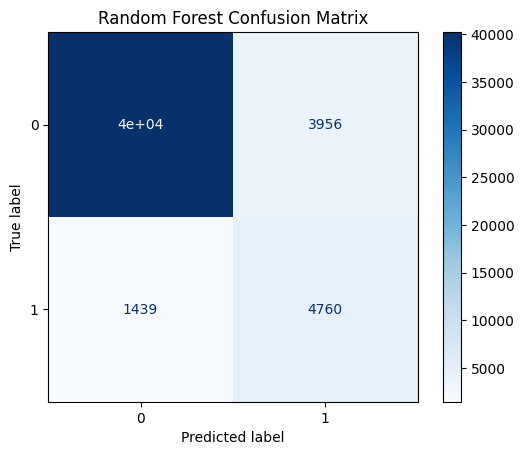

In [197]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    best_rf,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.show()

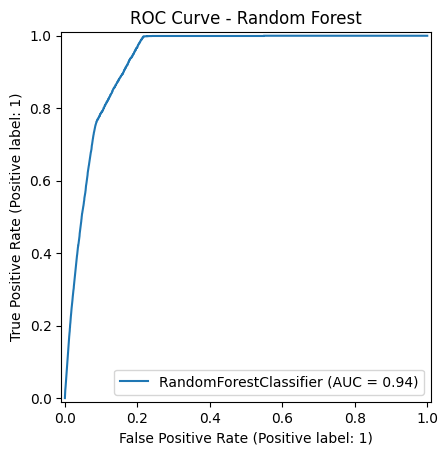

In [198]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_estimator(
    best_rf,
    X_test,
    y_test
)

plt.title("ROC Curve - Random Forest")
plt.show()

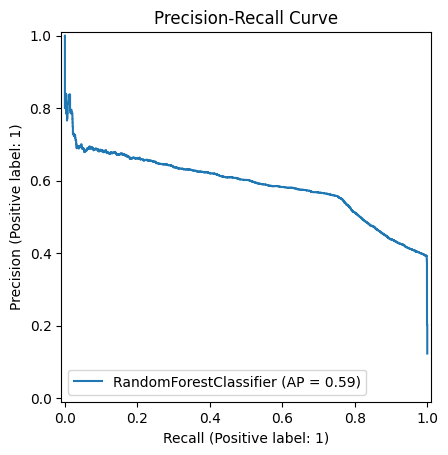

In [199]:
from sklearn.metrics import PrecisionRecallDisplay
import matplotlib.pyplot as plt

PrecisionRecallDisplay.from_estimator(
    best_rf,
    X_test,
    y_test
)

plt.title("Precision-Recall Curve")
plt.show()

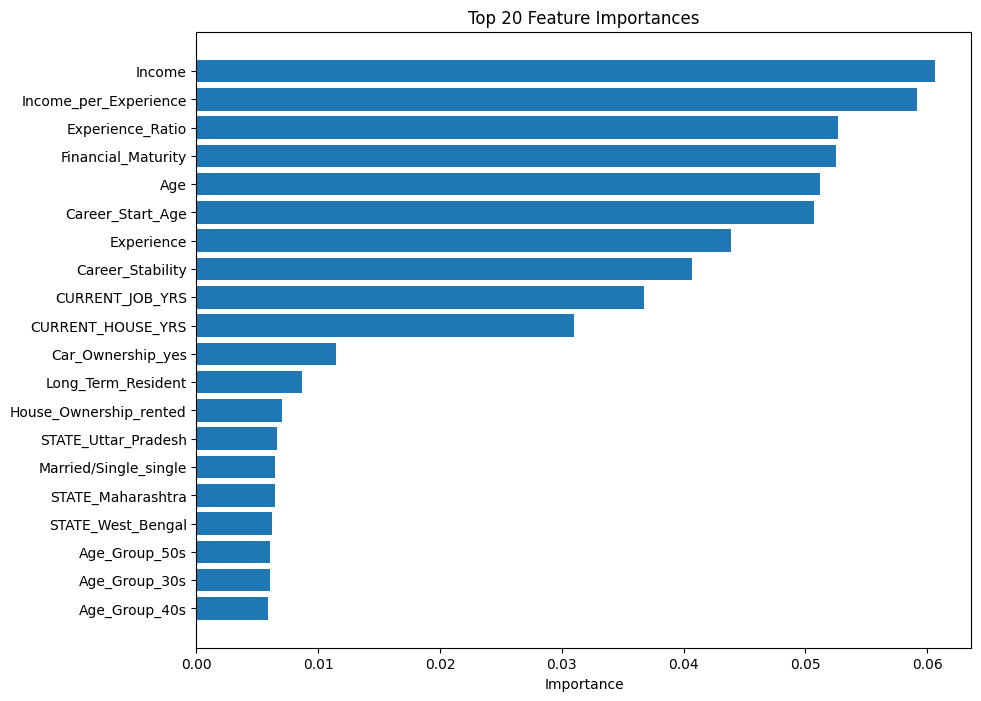

In [200]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
).head(20)

plt.figure(figsize=(10,8))
plt.barh(
    importance["Feature"],
    importance["Importance"]
)
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances")
plt.xlabel("Importance")
plt.show()

In [201]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    best_rf,
    X_train,
    y_train,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

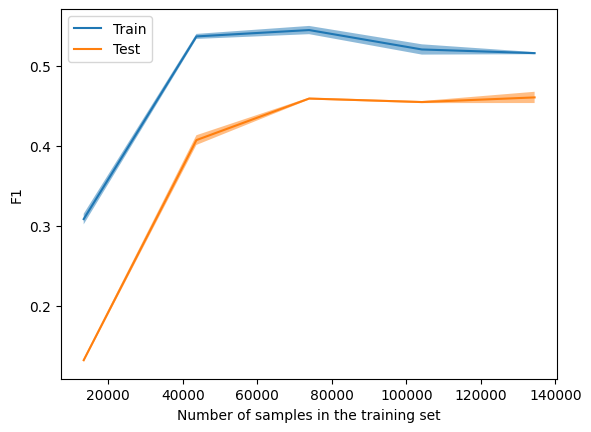

In [202]:
from sklearn.model_selection import LearningCurveDisplay

LearningCurveDisplay.from_estimator(
    best_rf,
    X_train,
    y_train,
    cv=3,
    scoring="f1"
)

plt.show()